<a href="https://colab.research.google.com/github/JoseAlberto88/Predictive-Maintenance-Dataset/blob/main/Predictive_Maintenance_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAMO-510-8. Predictive Analytics
## Take-Home Assignment 2: Predictive Maintenance. Machine Failure Prediction


**Course:** Predictive Analytics (DAMO-510-8)

**Term:** Summer 2026

**Instructor:** Prof. Payman Janbakhsh

**Student:** Jose Alberto Martinez Morales

---

## Background

Unexpected machine failures can cause production delays, increased maintenance costs, safety concerns, and operational disruption. Predictive analytics can support maintenance planning by identifying machines that exhibit operating conditions associated with a higher risk of failure.

In this assignment, you will develop and critically evaluate classification models using the AI4I 2020 Predictive Maintenance Dataset.

The purpose of this assignment is not simply to obtain the highest model accuracy. You are expected to demonstrate appropriate analytical judgement regarding data preparation, variable selection, class imbalance, model development, evaluation, interpretation, and operational decision-making.

## Dataset

Use the AI4I 2020 Predictive Maintenance Dataset from the UCI Machine Learning Repository:

https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

**Target variable:** `Machine failure`

You must use the original dataset obtained from the stated source.


In [38]:
# For this assignment, I will save the Maintenance Dataset in my Google drive and call it using code.
# If you want to run the jupyter notebook in your local machine, please change the directory described in the next code block.

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import pandas as pd

DATA_FILE = '/content/drive/MyDrive/Predictive Analytics Course/Maintenance Dataset.csv'
df = pd.read_csv(DATA_FILE)

# To check the 5 first observations of the dataset
print("Initial shape:", df.shape)
df.head()

Initial shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Assignment Tasks

### Task 1. Problem Definition

Define the predictive problem represented by the dataset.

Your discussion must:

- clearly identify the target variable and classes;
- explain the purpose of predicting machine failure;
- identify potential users of such a prediction system;
- distinguish between the operational consequences of false-positive and false-negative predictions; and
- identify the evaluation criteria you believe should receive the greatest emphasis in this problem.

Support your choices using the context of predictive maintenance rather than generic definitions of classification.

### Task 1. Problem Definition

#### **Explanation: Target Variables and Classes**
The AI4I 2020 dataset frames a binary classification problem centred on the variable **Machine failure**, which takes the value 1 when a machine tool has experienced at least one of five recorded failure modes during an operating cycle (tool wear failure, heat dissipation failure, power failure, overstrain failure, or random failure) and 0 when it has not. Of the 10,000 recorded observations, failures are a small minority of cases, which already signals that this is a rare-event detection problem rather than a balanced discrimination task, a point that shapes every later modelling decision, from the choice of resampling strategy to the metrics used to judge success.

#### **Explanation: Purpose of Predicting Machine Failure**
The purpose of predicting machine failure is to shift maintenance activity away from the two conventional regimes that dominate manufacturing operations. Purely reactive maintenance repairs a machine only after it has broken, which guarantees unplanned downtime, and time-based preventive maintenance services equipment on a fixed schedule regardless of its actual condition, which wastes labour and parts on machines that did not need attention while still missing failures that occur between scheduled visits. A predictive model that flags an elevated failure risk from live operating conditions, such as temperatures, rotational speed, torque, and tool wear,  allows maintenance to be triggered by the actual state of the machine rather than by the calendar or by failure itself, which is the basic value proposition of condition-based, predictive maintenance.


#### **Identification: Potential Users of such a Prediction System**
The natural users of such a system are the people who plan and execute maintenance work rather than the data science team that builds it: maintenance and reliability engineers who would use the model's output to prioritise inspection queues, production planners and plant managers who need advance warning to schedule downtime without disrupting delivery commitments, shop-floor technicians who would receive an operational alert rather than a probability score, and, indirectly, safety personnel, since several of the underlying failure modes (heat dissipation, overstrain) are also safety-relevant conditions. In practice, the model's output would most plausibly be consumed through a maintenance dashboard or a computerised maintenance management system (CMMS) rather than read directly as raw model output.

#### **Distintion: False-Positive and False-Negative Predictions**
Because this is a binary decision problem applied to a physical process, the two error types are not interchangeable, and treating them as symmetric would misrepresent the operational reality the model is meant to serve. A **false positive**, it means the model predicts failure when the machine is in fact healthy, triggers an unnecessary inspection or maintenance stoppage. This has a real but bounded cost: lost production time, technician labour, and, if false alarms are frequent, an erosion of operator trust that can lead staff to start ignoring the system altogether (alarm fatigue), which would defeat its purpose over time. A **false negative**, it means the model predicts no failure when the machine is about to fail, is materially more costly in most predictive-maintenance settings: it means the failure is discovered only when it actually occurs, with the same unplanned downtime, cascading equipment damage, and safety exposure that predictive maintenance was introduced to avoid, plus the reputational cost of a system that failed to warn when it was supposed to. Because the dataset also implies a low base rate of failure, the asymmetry compounds: with failures scarce and their cost to miss high, a model that defaults toward the majority "no failure" prediction can look accurate while providing little of the protection the business actually needs.

#### **Identification and Evaluation Criteria**
This asymmetry is what should drive the choice of evaluation criteria, and it argues against using overall accuracy as the primary yardstick, since with failures forming a small share of observations a trivial always-predict-no-failure model would already score highly on accuracy while being operationally useless. The metric that should receive the greatest emphasis is **recall on the failure class** (the proportion of actual failures the model successfully flags), because in this problem missing a failure is more expensive than issuing an avoidable inspection. Recall should not be optimised in isolation, however: a model that maximises recall by flagging almost everything as high-risk would generate so many false alarms that maintenance staff could not act on them meaningfully, so **precision** and a metric that balances the two (F1, or an F-beta score that weights recall above precision to reflect the cost asymmetry) should be tracked alongside it, together with a threshold-independent measure such as **ROC-AUC** to assess the model's underlying ability to separate failing from healthy machines before any specific operating threshold is chosen. This combination, recall-weighted performance on the minority class, checked against precision to keep false alarms manageable, and summarised by a threshold-independent ranking metric, reflects how the model would actually be judged and operated in a predictive-maintenance context, rather than how a classifier is conventionally scored in a balanced, generic setting.


### Task 2. Data Audit

Conduct an audit of the original dataset.

Your submission must provide evidence regarding:

- dataset dimensions;
- variable types;
- target distribution;
- missing information;
- duplicate observations;
- unusual or potentially problematic values;
- categorical and numerical predictors;
- identifier-like variables; and
- any variables that may create data leakage.

Determine which variables should and should not be included in your predictive model. You must justify all exclusions.

Special attention must be given to: **TWF, HDF, PWF, OSF, and RNF**.

Simply removing these variables without explaining your reasoning is insufficient.

#### **Dimensions, types, target distribution:**

In [40]:
# Dataset dimentions
print("Shape (rows, columns):", df.shape)

# Variballe types
print(df.dtypes)
df.info()

# target distribution
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True) * 100)

Shape (rows, columns): (10000, 14)
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K] 

#### **Missing values and duplicates**

In [41]:
# Missing information
missing_summary = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_pct' : (df.isnull().mean() * 100).round(2)
})

print(missing_summary)

# Duplicates observations
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate UDI values:", df['UDI'].duplicated().sum())
print("Duplicate Product ID values:", df['Product ID'].duplicated().sum())

feature_cols = df.columns.difference(['UDI', 'Product ID'])

print("Duplicate feature combos (excl. identifiers):", df.duplicated(subset=feature_cols).sum())

                         missing_count  missing_pct
UDI                                  0          0.0
Product ID                           0          0.0
Type                                 0          0.0
Air temperature [K]                  0          0.0
Process temperature [K]              0          0.0
Rotational speed [rpm]               0          0.0
Torque [Nm]                          0          0.0
Tool wear [min]                      0          0.0
Machine failure                      0          0.0
TWF                                  0          0.0
HDF                                  0          0.0
PWF                                  0          0.0
OSF                                  0          0.0
RNF                                  0          0.0
Fully duplicated rows: 0
Duplicate UDI values: 0
Duplicate Product ID values: 0
Duplicate feature combos (excl. identifiers): 0


#### **Unusual/problematic values (physical plausibility plus outliers)**



In [42]:
numeric_cols = ["Air temperature [K]", "Process temperature [K]",
                 "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
print(df[numeric_cols].describe().T)

print("Negative values:\n", (df[numeric_cols] == 0).sum())

print("Zero values:\n", (df[numeric_cols] == 0).sum())
print("Process temp <= Air temp rows:", (df['Process temperature [K]'] <= df['Air temperature [K]']).sum())

print(df['Type'].value_counts())

for col in numeric_cols:
  q1, q3 = df[col].quantile([0.25, 0.75])
  iqr = q3 - q1
  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr
  n_out = ((df[col] < lower) | (df[col] > upper)).sum()
  print(f"{col}: {n_out} IQR outliers")

                           count        mean         std     min     25%  \
Air temperature [K]      10000.0   300.00493    2.000259   295.3   298.3   
Process temperature [K]  10000.0   310.00556    1.483734   305.7   308.8   
Rotational speed [rpm]   10000.0  1538.77610  179.284096  1168.0  1423.0   
Torque [Nm]              10000.0    39.98691    9.968934     3.8    33.2   
Tool wear [min]          10000.0   107.95100   63.654147     0.0    53.0   

                            50%     75%     max  
Air temperature [K]       300.1   301.5   304.5  
Process temperature [K]   310.1   311.1   313.8  
Rotational speed [rpm]   1503.0  1612.0  2886.0  
Torque [Nm]                40.1    46.8    76.6  
Tool wear [min]           108.0   162.0   253.0  
Negative values:
 Air temperature [K]          0
Process temperature [K]      0
Rotational speed [rpm]       0
Torque [Nm]                  0
Tool wear [min]            120
dtype: int64
Zero values:
 Air temperature [K]          0
Process temp

#### **Identifier check:**



In [43]:
# Identifier like variables
print("Unique UDI:", df['UDI'].nunique(), "of", len(df))
print("Unique Product ID:", df['Product ID'].nunique(), "of", len(df))
print("Product ID prefix == Type in",
      (df['Product ID'].str[0] == df['Type']).mean() * 100, "% of rows")

Unique UDI: 10000 of 10000
Unique Product ID: 10000 of 10000
Product ID prefix == Type in 100.0 % of rows


#### **The leakage check for TWF, HDF, PWF, OSF, RNF**

In [44]:
leak_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for col in leak_cols:
    print(col, "vs Machine failure:\n", pd.crosstab(df[col], df['Machine failure']))

implied_failure = (df[leak_cols].sum(axis=1) > 0).astype(int)
agreement = (implied_failure == df['Machine failure']).mean() * 100
print(f"Agreement between OR(TWF..RNF) and Machine failure: {agreement:.2f}%")

mismatch = df[implied_failure != df['Machine failure']]
print("Mismatched rows:", len(mismatch))
print(mismatch[['Machine failure'] + leak_cols].head(10))

TWF vs Machine failure:
 Machine failure     0    1
TWF                       
0                9661  293
1                   0   46
HDF vs Machine failure:
 Machine failure     0    1
HDF                       
0                9661  224
1                   0  115
PWF vs Machine failure:
 Machine failure     0    1
PWF                       
0                9661  244
1                   0   95
OSF vs Machine failure:
 Machine failure     0    1
OSF                       
0                9661  241
1                   0   98
RNF vs Machine failure:
 Machine failure     0    1
RNF                       
0                9643  338
1                  18    1
Agreement between OR(TWF..RNF) and Machine failure: 99.73%
Mismatched rows: 27
      Machine failure  TWF  HDF  PWF  OSF  RNF
1221                0    0    0    0    0    1
1302                0    0    0    0    0    1
1437                1    0    0    0    0    0
1748                0    0    0    0    0    1
2072                0

#### **Final inclusion/exclusion decision:**

In [45]:
excluded_vars = ['UDI', 'Product ID'] + leak_cols
included_predictors = ['Type'] + numeric_cols
df_model = df[included_predictors + ['Machine failure']].copy()
print(df_model.shape)
df_model.head()

(10000, 7)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## Task 2. Data Audit Conclusion

The dataset, obtained from the UCI AI4I 2020 Predictive Maintenance repository, contains 10,000 observations and 14 variables, with no missing values in any column and no fully duplicated rows. Both identifier columns are confirmed unique (10,000 distinct UDI values and 10,000 distinct Product ID values across 10,000 rows), and re-checking duplication on the feature columns alone, i.e. ignoring the two identifiers, still returns zero duplicate rows, so no observations were removed at the audit stage.

**Variable roles.** The 14 columns fall into five functional groups, summarised below together with the audit decision reached for each:

| Group | Variables | Type | Audit decision |
|---|---|---|---|
| Identifiers | UDI, Product ID | int / object | Excluded |
| Categorical predictor | Type | object (L/M/H) | Retained |
| Numerical predictors | Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min] | float / int | Retained |
| Target | Machine failure | int (0/1) | Target |
| Failure-mode flags | TWF, HDF, PWF, OSF, RNF | int (0/1) | Excluded (data leakage) |

**Target distribution.** `Machine failure` is heavily imbalanced: 9,661 observations (96.61%) are non-failures and only 339 (3.39%) are failures, a ratio of roughly 28.5 non-failures for every failure. This confirms the framing in Task 1, accuracy is a poor primary metric here, and class imbalance must be addressed explicitly in preprocessing (Task 4) and investigated directly in Task 8.

**Unusual or problematic values.** None of the five numerical predictors contain negative or otherwise physically impossible values; the minimum of Tool wear is 0, and no other numerical column takes negative values. `Tool wear [min] = 0` occurs in 120 rows, which is a legitimate reading, the simulated wear counter resets to zero whenever a tool is replaced, rather than a data error, so these rows were retained. Process temperature exceeds air temperature in all 10,000 rows, which is physically consistent with heat generated by the machining process and gives no reason to suspect corrupted sensor readings. An IQR-based check flags 418 observations (4.2%) as high-side outliers on Rotational speed and 69 (0.7%) on Torque; because these values are neither negative nor implausible for a machining process operating outside its typical band, and because extreme torque/speed combinations are plausible precursors to overstrain, and power-related failures, they were treated as genuine extreme operating points rather than errors and were not removed, this is revisited in the exploratory analysis (Task 3) as a candidate driver of failure risk rather than noise to be filtered out. The categorical `Type` column contains exactly three valid levels (L = 6,000, M = 2,997, H = 1,003) with no misspellings or stray categories.

**Identifier-like variables.** UDI is a bare sequential row index (1 to 10,000, no repeats) and carries no information about machine condition; it was excluded. Product ID is also 100% unique per row, so it functions as a serial number rather than a predictor, and its first character was found to match the `Type` column in 100% of rows, confirming that the one piece of Product ID that is not a unique serial number (its L/M/H prefix) is fully redundant with `Type`, which is retained separately. Keeping Product ID in the model would risk the model keying on individual unit identity (a form of leakage/over-identification) rather than learning generalisable operating-condition patterns, so it was excluded along with UDI.

**Data leakage: TWF, HDF, PWF, OSF, RNF.** These five binary flags record which specific failure mechanism was involved in a machine-failure event (tool wear, heat dissipation, power, overstrain, and random failures respectively), and the audit shows why they cannot be used as predictors rather than simply asserting it. Checking whether `Machine failure` equals the logical OR of the five flags gives 99.73% agreement (9,973 of 10,000 rows), and the crosstabs make clear why the flags are leakage rather than merely correlated: for TWF, HDF, PWF and OSF, *every single row* where the flag equals 1 also has `Machine failure = 1` (e.g. all 46 TWF=1 rows, all 115 HDF=1 rows, all 95 PWF=1 rows, and all 98 OSF=1 rows are failures). These four flags are, in effect, a decomposition of the positive class into its failure mechanism, not an independent measurement taken before failure occurs. Including any of them would let the model read the label off a near-identical encoding of itself rather than learn from the underlying operating conditions.

RNF (random failure) behaves differently and is worth spelling out rather than lumping in with the other four: of the 19 rows where RNF = 1, only 1 corresponds to an actual `Machine failure = 1`; the other 18 are false triggers relative to the target. This is consistent with RNF being designed as a low-probability failure mode injected independently of the process parameters, so unlike the other four flags it does not leak the target, but it also carries essentially no genuine predictive signal (a 1-in-19 hit rate is barely different from noise) and, like the others, would not be knowable in advance of the outcome it nominally flags. It is excluded for a different reason than TWF/HDF/PWF/OSF: not because it gives the answer away, but because it is uninformative and, by construction, unobservable ahead of the failure event it is meant to represent.

The 27 rows (0.27%) where `Machine failure` and OR(TWF..RNF) disagree also split into two informative patterns: the 18 RNF-only false triggers described above, and roughly 9 rows where `Machine failure = 1` but none of the five flags is set, cases such as UDI rows 1437, 2749 and 4044, where a failure is recorded with all five mode flags at 0. This indicates the five flags do not perfectly span every real failure mechanism captured in the simulation, reinforcing that they are a diagnostic sub-classification of the target rather than a set of independent, always-available predictors, and that a model should be learning failure risk from the continuous sensor variables rather than from this near-tautological encoding of the label. All five flags (TWF, HDF, PWF, OSF, RNF) are therefore excluded from the predictive model on both statistical grounds (near-total agreement with the target for four of the five) and operational grounds (none of the five would be known at the point an early-warning prediction needs to be made).

**Final variable set.** After the audit, the modelling frame retains `Type` and the five continuous sensor variables (Air temperature, Process temperature, Rotational speed, Torque, Tool wear) as predictors, with `Machine failure` as the target; UDI, Product ID, TWF, HDF, PWF, OSF and RNF are excluded for the reasons documented above.


### Task 3. Exploratory Investigation

Conduct an exploratory investigation of the predictors and the target.

Your analysis must identify **at least five findings** that could potentially affect:

- preprocessing;
- feature selection;
- model choice;
- class-imbalance treatment; or
- interpretation of the final model.

At least **two findings** must involve relationships between multiple variables rather than a single-variable distribution.

Provide appropriate supporting tables or visualizations. For every finding, explain why it matters to the predictive problem.


In [46]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Output folder on Google Drive (Colab)
# Creates a "visuals" subfolder next to the dataset and saves every figure there.
OUTPUT_DIR = '/content/drive/MyDrive/Predictive Analytics Course/visuals'
os.makedirs(OUTPUT_DIR, exist_ok=True)


def savefig(filename):
    """Save the current figure into the Drive visuals folder."""
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')

# ---- Shared style / palette (kept consistent across all EDA figures) ----
# Softer, pastel-leaning pair -- still validated for lightness band, chroma floor,
# and colorblind (CVD) separation; the contrast-vs-surface check lands in the WARN
# band, so every chart using these colors keeps direct value labels / a legend
# alongside the color (the required "relief" for that warning).
COLOR_NO_FAILURE = "#5b9bd5"   # pastel blue
COLOR_FAILURE    = "#e8767a"   # pastel coral/red
AXIS_COLOR       = "#c3c2b7"
TEXT_MUTED       = "#898781"
TEXT_PRIMARY     = "#0b0b0b"

# Separate categorical palette for product Type (L/M/H) -- deliberately distinct
# hues from the blue/coral failure-status pair above, so a reader never confuses
# "which Type" color with "did it fail" color across figures. Validated (3-slot
# categorical): passes lightness band, chroma floor, and CVD/normal-vision
# separation checks.
TYPE_COLORS = {
    'H': "#9c8ee0",   # pastel violet
    'L': "#2fa38a",   # pastel teal
    'M': "#d9a23b",   # pastel amber
}

# Diverging pastel blue<->coral colormap with a neutral gray midpoint, for correlation heatmaps
# (this encodes correlation polarity, not failure class, so it keeps the blue/coral
# pair above rather than switching to the green/red pair below)
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#5b9bd5", "#f0efec", "#e8767a"], N=256
)

# Stronger pastel green/red pair, used only in the multivariate scatter figures
# (3.4b, 3.5, 3.6) where points are dense and a bolder contrast reads better.
# Validated: CVD (deutan) separation Delta E 10.8, clearing the >=8 target
# (a plain red/green pair typically fails this -- this one does not).
COLOR_NO_FAILURE_STRONG = "#57b894"   # strong pastel green
COLOR_FAILURE_STRONG    = "#d94f4f"   # strong pastel red

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS_COLOR,
    "axes.grid": False,          # no gridlines
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "text.color": TEXT_PRIMARY,
    "axes.labelcolor": TEXT_PRIMARY,
    "axes.titlepad": 14,          # extra space between title and plot area
    "font.size": 10,
})

numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
target_col = 'Machine failure'


Class counts:
 Machine failure
0    9661
1     339
Name: count, dtype: int64
Class %:
 Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64
Imbalance ratio (no-failure : failure) = 28.5 : 1


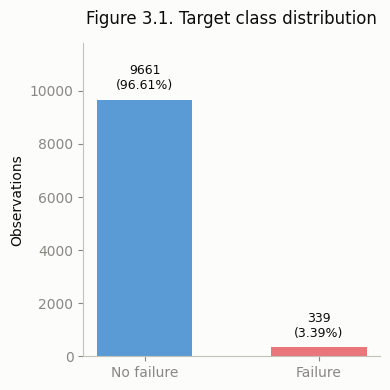

In [47]:
# Finding 3.1 (single-variable). Target class imbalance

counts = df[target_col].value_counts().sort_index()
pct = df[target_col].value_counts(normalize=True).sort_index() * 100
imbalance_ratio = counts[0] / counts[1]
print("Class counts:\n", counts)
print("Class %:\n", pct.round(2))
print(f"Imbalance ratio (no-failure : failure) = {imbalance_ratio:.1f} : 1")

fig, ax = plt.subplots(figsize=(4, 4))
ax.grid(False)
ax.bar(['No failure', 'Failure'], counts.values,
       color=[COLOR_NO_FAILURE, COLOR_FAILURE], width=0.55)
ax.set_ylim(0, counts.values.max() * 1.22)   # headroom so labels/title never collide with bars
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.values.max() * 0.03, f"{v}\n({pct.values[i]:.2f}%)",
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel("Observations")
ax.set_title("Figure 3.1. Target class distribution")
plt.tight_layout()
savefig("fig3_1_target_distribution.png")
plt.show()

Tool wear [min] by class:
                    mean  median    std
Machine failure                       
0                106.69   107.0  62.95
1                143.78   165.0  72.76


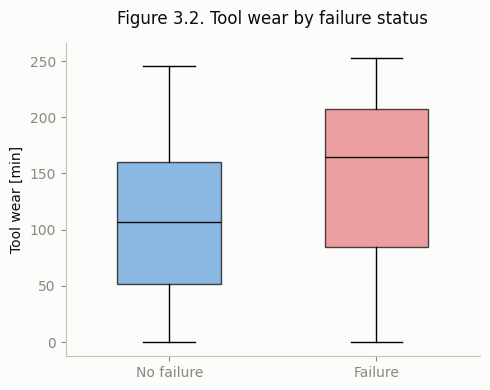

In [48]:
# Finding 3.2 (single-variable). Tool wear by failure status

wear_by_class = df.groupby(target_col)['Tool wear [min]'].agg(['mean', 'median', 'std'])
print("Tool wear [min] by class:\n", wear_by_class.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
ax.grid(False)
box_data = [df.loc[df[target_col] == 0, 'Tool wear [min]'],
            df.loc[df[target_col] == 1, 'Tool wear [min]']]
bp = ax.boxplot(box_data, tick_labels=['No failure', 'Failure'], patch_artist=True,
                 widths=0.5, medianprops=dict(color=TEXT_PRIMARY))
for patch, color in zip(bp['boxes'], [COLOR_NO_FAILURE, COLOR_FAILURE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Tool wear [min]")
ax.set_title("Figure 3.2. Tool wear by failure status")
plt.tight_layout()
savefig("fig3_2_toolwear_by_failure.png")
plt.show()



      n_observations  n_failures  failure_rate  failure_rate_pct
Type                                                            
H               1003          21      0.020937              2.09
L               6000         235      0.039167              3.92
M               2997          83      0.027694              2.77


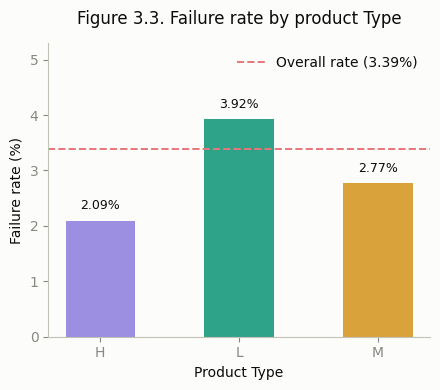

In [49]:
# Finding 3.3 (single-variable, categorical). Failure rate by product Type

type_summary = df.groupby('Type')[target_col].agg(['count', 'sum', 'mean'])
type_summary.columns = ['n_observations', 'n_failures', 'failure_rate']
type_summary['failure_rate_pct'] = (type_summary['failure_rate'] * 100).round(2)
type_summary = type_summary.sort_index()
print(type_summary)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.grid(False)
bar_colors = [TYPE_COLORS[t] for t in type_summary.index]
ax.bar(type_summary.index, type_summary['failure_rate_pct'], color=bar_colors, width=0.5)
overall_rate = df[target_col].mean() * 100
ax.axhline(overall_rate, color=COLOR_FAILURE, linestyle='--', linewidth=1.4,
           label=f"Overall rate ({overall_rate:.2f}%)")
ax.set_ylim(0, type_summary['failure_rate_pct'].max() * 1.35)
for i, (idx, row) in enumerate(type_summary.iterrows()):
    ax.text(i, row['failure_rate_pct'] + type_summary['failure_rate_pct'].max() * 0.04,
            f"{row['failure_rate_pct']:.2f}%", ha='center', va='bottom', fontsize=9)
ax.set_ylabel("Failure rate (%)")
ax.set_xlabel("Product Type")
ax.set_title("Figure 3.3. Failure rate by product Type")
ax.legend(frameon=False, loc='upper right')
plt.tight_layout()
savefig("fig3_3_failure_rate_by_type.png")
plt.show()


                         Air temperature [K]  Process temperature [K]  \
Air temperature [K]                    1.000                    0.876   
Process temperature [K]                0.876                    1.000   
Rotational speed [rpm]                 0.023                    0.019   
Torque [Nm]                           -0.014                   -0.014   
Tool wear [min]                        0.014                    0.013   

                         Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
Air temperature [K]                       0.023       -0.014            0.014  
Process temperature [K]                   0.019       -0.014            0.013  
Rotational speed [rpm]                    1.000       -0.875            0.000  
Torque [Nm]                              -0.875        1.000           -0.003  
Tool wear [min]                           0.000       -0.003            1.000  


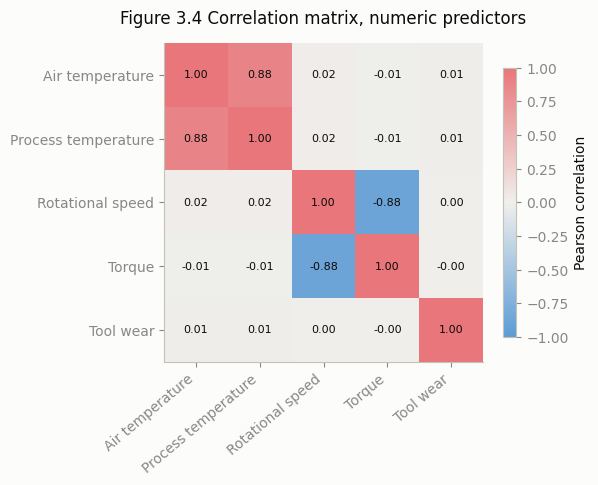

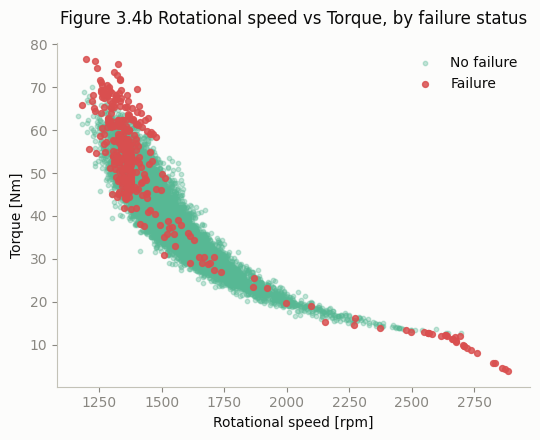

In [50]:
# Finding 3.4 (MULTI-variable) -- Correlation among numeric predictors

corr_matrix = df[numeric_cols].corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
short_labels = [c.split(' [')[0] for c in numeric_cols]
ax.set_xticklabels(short_labels, rotation=40, ha='right')
ax.set_yticklabels(short_labels)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center',
                fontsize=8, color=TEXT_PRIMARY)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Figure 3.4 Correlation matrix, numeric predictors")
plt.tight_layout()
savefig("fig3_4_correlation_heatmap.png")
plt.show()

# Scatter: Rotational speed vs Torque, colored by failure status
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for cls, color, label in [(0, COLOR_NO_FAILURE_STRONG, 'No failure'), (1, COLOR_FAILURE_STRONG, 'Failure')]:
    subset = df[df[target_col] == cls]
    ax.scatter(subset['Rotational speed [rpm]'], subset['Torque [Nm]'],
               s=10 if cls == 0 else 18, alpha=0.35 if cls == 0 else 0.85,
               color=color, label=label)
ax.set_xlabel("Rotational speed [rpm]")
ax.set_ylabel("Torque [Nm]")
ax.set_title("Figure 3.4b Rotational speed vs Torque, by failure status")
ax.legend(frameon=False)
plt.tight_layout()
savefig("fig3_4b_speed_vs_torque.png")
plt.show()

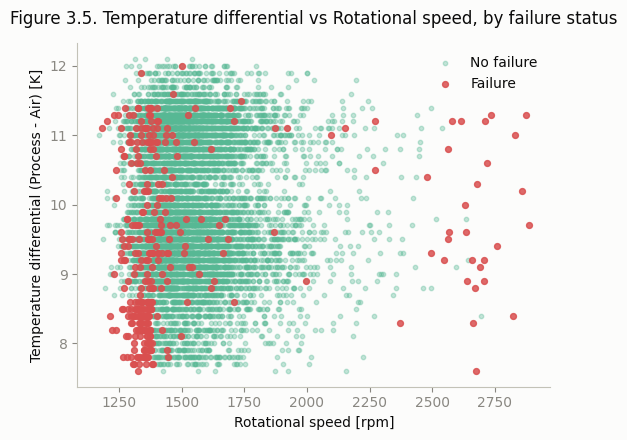

Rows in risk zone (speed<1400rpm AND temp_diff<8.6K): 150 (1.50% of data)
Failure rate inside risk zone:  77.33%
Failure rate outside risk zone: 2.26%
Overall failure rate:           3.39%
Lift (zone rate / overall rate): 22.81x


In [51]:
# Finding 3.5 (MULTI-variable). Temperature differential x Rotational speed

temp_diff = df['Process temperature [K]'] - df['Air temperature [K]']

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for cls, color, label in [(0, COLOR_NO_FAILURE_STRONG, 'No failure'), (1, COLOR_FAILURE_STRONG, 'Failure')]:
    mask = df[target_col] == cls
    ax.scatter(df.loc[mask, 'Rotational speed [rpm]'], temp_diff[mask],
               s=10 if cls == 0 else 18, alpha=0.35 if cls == 0 else 0.85,
               color=color, label=label)
ax.set_xlabel("Rotational speed [rpm]")
ax.set_ylabel("Temperature differential (Process - Air) [K]")
ax.set_title("Figure 3.5. Temperature differential vs Rotational speed, by failure status")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig3_5_tempdiff_vs_speed.png", dpi=150)
plt.show()

# Quantify the apparent low-speed / low-temp-diff risk zone with a lift calculation
low_speed = df['Rotational speed [rpm]'] < 1400
low_tempdiff = temp_diff < 8.6
risk_zone = low_speed & low_tempdiff

overall_failure_rate = df[target_col].mean()
zone_failure_rate = df.loc[risk_zone, target_col].mean()
outside_zone_failure_rate = df.loc[~risk_zone, target_col].mean()
lift = zone_failure_rate / overall_failure_rate

print(f"Rows in risk zone (speed<1400rpm AND temp_diff<8.6K): {risk_zone.sum()} ({risk_zone.mean()*100:.2f}% of data)")
print(f"Failure rate inside risk zone:  {zone_failure_rate*100:.2f}%")
print(f"Failure rate outside risk zone: {outside_zone_failure_rate*100:.2f}%")
print(f"Overall failure rate:           {overall_failure_rate*100:.2f}%")
print(f"Lift (zone rate / overall rate): {lift:.2f}x")


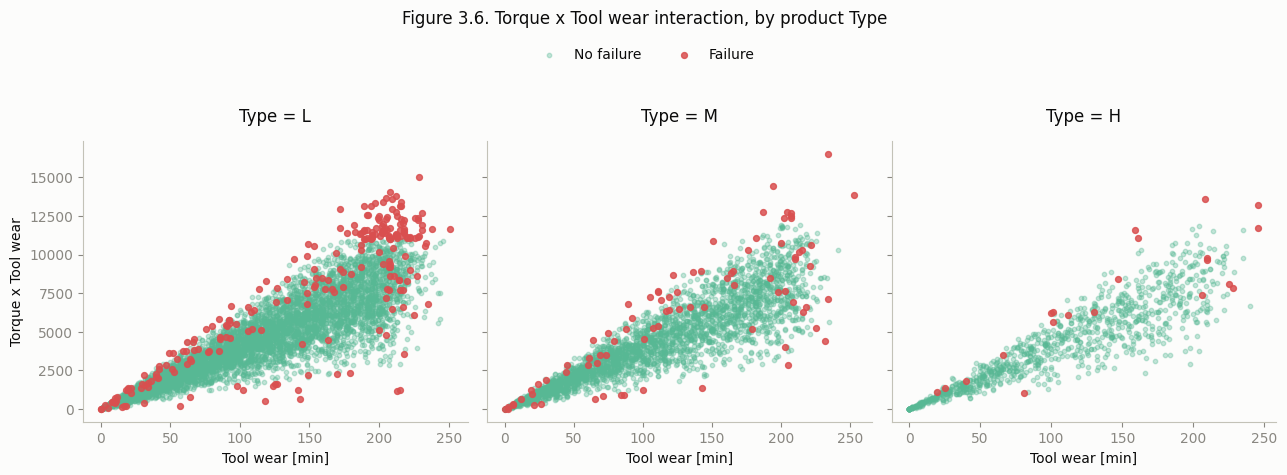

Correlation(Torque x Tool wear, Machine failure) overall: 0.190
  Type=L: correlation=0.226, n=6000, 99th pct of product=11346
  Type=M: correlation=0.117, n=2997, 99th pct of product=10926
  Type=H: correlation=0.155, n=1003, 99th pct of product=10752


In [52]:
# Finding 3.6 (MULTI-variable) Torque x Tool wear interaction, by Type

torque_wear_product = df['Torque [Nm]'] * df['Tool wear [min]']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, t in zip(axes, ['L', 'M', 'H']):
    mask_type = df['Type'] == t
    for cls, color, label in [(0, COLOR_NO_FAILURE_STRONG, 'No failure'), (1, COLOR_FAILURE_STRONG, 'Failure')]:
        mask = mask_type & (df[target_col] == cls)
        ax.scatter(df.loc[mask, 'Tool wear [min]'], torque_wear_product[mask],
                   s=10 if cls == 0 else 18, alpha=0.35 if cls == 0 else 0.85,
                   color=color, label=label if t == 'L' else None)
    ax.set_title(f"Type = {t}")
    ax.set_xlabel("Tool wear [min]")
axes[0].set_ylabel("Torque x Tool wear")
fig.legend(loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.06))
fig.suptitle("Figure 3.6. Torque x Tool wear interaction, by product Type", y=1.12)
plt.tight_layout()
plt.savefig("fig3_6_torque_wear_by_type.png", dpi=150, bbox_inches='tight')
plt.show()

# Correlation of the interaction term with the target, overall and by Type
corr_overall = np.corrcoef(torque_wear_product, df[target_col])[0, 1]
print(f"Correlation(Torque x Tool wear, Machine failure) overall: {corr_overall:.3f}")

for t in ['L', 'M', 'H']:
    mask_type = df['Type'] == t
    c = np.corrcoef(torque_wear_product[mask_type], df.loc[mask_type, target_col])[0, 1]
    q99 = torque_wear_product[mask_type].quantile(0.99)
    print(f"  Type={t}: correlation={c:.3f}, n={mask_type.sum()}, 99th pct of product={q99:.0f}")

## Task 3. Exploratory Investigation Conclusion

The exploratory investigation examined six findings built on the retained predictors and target: three single-variable (3.1–3.3) and three multi-variable (3.4/3.4b, 3.5, 3.6).

**Finding 3.1: Target class imbalance (single-variable).** Figure 3.1 confirms the class split already established in the Task 2 audit: 9,661 no-failure observations (96.61%) against 339 failures (3.39%), an imbalance ratio of 28.5:1. Restating it here as an EDA finding rather than an audit fact matters because it is the single most consequential property of the dataset for everything downstream. It rules out plain accuracy as a usable metric (Task 1), it means stratified train/test splitting is mandatory to avoid a test set with too few positives to evaluate reliably, and it directly motivates the imbalance-management comparison required in Task 8 (e.g., class weighting, SMOTE, or threshold movement) rather than treating imbalance as a detail to fix later.

**Finding 3.2: Tool wear by failure status (single-variable).** Grouped by `Machine failure`, tool wear is both higher and more dispersed for failures: mean 143.78 min versus 106.69 min, median 165.0 versus 107.0, and standard deviation 72.76 versus 62.95 (Figure 3.2). The gap between the mean and the (higher) median for failures indicates a left-skewed distribution among failures, many failures occur only after substantial wear has accumulated, consistent with a wear-driven failure mechanism (TWF) even though that flag itself is excluded as leakage. This matters for model choice: the relationship looks more like a rising-then-flattening risk with wear rather than a clean linear one, which favours tree-based models (Decision Tree, Random Forest, XGBoost) that can split on wear thresholds directly, over logistic regression unless wear is transformed or binned first.

**Finding 3.3: Failure rate by product Type (single-variable, categorical).** Failure rate is not uniform across product Type: L = 3.92% (235 of 6,000), M = 2.77% (83 of 2,997), and H = 2.09% (21 of 1,003), against an overall rate of 3.39% (Figure 3.3). Type L machines fail nearly twice as often as Type H despite making up the majority of the data. This confirms `Type` carries real predictive signal and should be retained and encoded (one-hot or ordinal, Task 4) rather than treated as a nuisance identifier, and it motivates checking whether other relationships in the data, such as the torque/wear interaction in Finding 3.6, differ by Type rather than assuming one relationship holds for the whole fleet.

**Finding 3.4 / 3.4b: Correlation structure and the speed–torque relationship (multi-variable).** The correlation matrix (Figure 3.4) shows two strong pairwise relationships among the five numeric predictors and near-zero correlation everywhere else: Air temperature and Process temperature correlate at 0.876, and Rotational speed and Torque correlate at −0.875, while Tool wear is essentially uncorrelated with every other predictor (|r| ≤ 0.02). Plotting Rotational speed against Torque and colouring by failure status (Figure 3.4b) shows the expected near-reciprocal curve (consistent with roughly constant power draw) with failures concentrated in the upper-left region, low speed paired with high torque, rather than spread evenly along the curve. This has two consequences. First, the 0.876 and −0.875 collinearities mean logistic regression should not use all five raw predictors unregularised: multicollinearity inflates coefficient variance and makes individual coefficients hard to interpret, so this pushes toward regularisation (L2/elastic-net) or a reduced/engineered feature set for the linear model, whereas the tree-based models are largely insensitive to it. Second, because failures cluster in a specific corner of the speed–torque plane rather than along the whole relationship, a single "low speed" or "high torque" threshold considered in isolation would miss the pattern — it is the joint low-speed/high-torque combination that matters, which is exactly the kind of interaction that motivates engineered interaction features (Task 5) and that tree ensembles capture more naturally than an additive linear model.

**Finding 3.5: Temperature differential × Rotational speed defines a high-lift risk zone (multi-variable).** Neither Air temperature nor Process temperature correlates meaningfully with the target on its own (Finding 3.4, |r| ≈ 0.02), yet their difference behaves very differently once combined with Rotational speed. Plotting the engineered temperature differential (Process − Air) against Rotational speed (Figure 3.5) reveals a dense concentration of failures in the low-speed / low-differential corner. Formalising this as a rule, Rotational speed < 1,400 rpm AND temperature differential < 8.6 K, defines a zone containing only 150 rows (1.50% of the data) but with a 77.33% failure rate inside the zone versus 2.26% outside it and 3.39% overall, a 22.81× lift. This is the strongest single pattern found in the exploratory analysis, and it matters for three reasons: it demonstrates that two individually weak predictors (temperature differential is only implicitly present in the two raw temperature columns) can combine into a strong joint signal, which is a direct, evidence-based justification for engineering the temperature-differential feature in Task 5 rather than leaving the model to rediscover it from the two raw temperatures; it shows the risk is highly localised rather than smoothly graded, again favouring models that can carve out axis-aligned or near-axis-aligned regions (trees/ensembles) over a plain linear boundary; and because the zone is small (1.5% of rows) but highly informative, it is a natural region to revisit during misclassification analysis (Task 11) and threshold selection (Task 10), a model that fails to flag this specific corner would be missing a disproportionate share of recoverable recall.

**Finding 3.6: Torque × Tool wear interaction, moderated by product Type (multi-variable).** The product of Torque and Tool wear correlates with `Machine failure` at r = 0.190 overall, noticeably stronger than Tool wear alone (Finding 3.2) or Torque alone. Figure 3.6 stratifies this relationship by Type and shows both the interaction's value and its inconsistency across the fleet: Type L shows the strongest association (r = 0.226, n = 6,000) with a visually distinct band of failures clustering above roughly the 99th percentile of the interaction term ( approximatelly 11,346), Type H is intermediate (r = 0.155, n = 1,003), and Type M is weakest (r = 0.117, n = 2,997, 99th percentile, approximatelly  10,926). This matters in two ways: it is a second, independent justification (alongside Finding 3.5) for the interaction-feature requirement in Task 5, since Torque × Tool wear again outperforms its individual components; and the fact that the strength of the relationship depends on Type means a single global interaction feature will not capture the whole picture, this is worth revisiting in Task 12 (model interpretation) to see whether the models' learned feature importances for Torque × Tool wear (or for Type itself) reflect this Type-dependent moderation, and it flags a possible case for a Type-interaction term if a chosen model's performance on Type L specifically remains a priority.

**Summary and implications for later tasks.** Taken together, the six findings converge on a consistent picture: individual raw predictors carry only weak, and in Tool wear's and Type's case moderate, association with `Machine failure` on their own, but two engineered combinations, temperature differential × rotational speed and torque × tool wear, expose much stronger, highly localised risk signals (22.81× lift and r = 0.190 respectively) that are not visible in the univariate or correlation-matrix view alone. This is the central evidentiary basis for the feature engineering carried out in Task 5, argues for tree-based models (Decision Tree, Random Forest, XGBoost) as strong candidates over unregularised logistic regression given the collinearity in Finding 3.4 and the non-additive, corner-concentrated risk pockets in Findings 3.5 and 3.6, and reinforces, alongside the imbalance quantified in Finding 3.1, why evaluation must go beyond accuracy and examine whether a model actually recovers the small, high-risk subpopulations identified here rather than the majority pattern.


### Task 4. Preprocessing Design

Design and implement your own preprocessing strategy.

Your submission must clearly identify:

- variables retained;
- variables removed;
- treatment of categorical variables;
- treatment of missing or invalid values, if applicable;
- transformations, if applicable;
- scaling decisions;
- treatment of class imbalance; and
- measures taken to prevent data leakage.

You must justify each major preprocessing decision. You are expected to distinguish between preprocessing that should be common to all models and preprocessing that may depend on the modelling algorithm.


## Task 4. Preprocessing Design Conclusion

The preprocessing strategy is built directly on the Task 2 audit and the Task 3 exploratory findings, and separates, throughout, what is applied identically to every model in Task 7 from what depends on which algorithm is being trained.

**Variables retained and removed.** The modelling frame carries forward the Task 2 decision unchanged: `Type` (categorical) and the five continuous sensor variables (Air temperature, Process temperature, Rotational speed, Torque, Tool wear) are retained as predictors, with `Machine failure` as the target. UDI, Product ID, and the five failure-mode flags (TWF, HDF, PWF, OSF, RNF) remain excluded, for the identifier-redundancy and leakage reasons already documented in Task 2.

**Order of operations and leakage prevention.** The single most important structural decision in this preprocessing design is sequencing: the data is split into training and test partitions (80/20, **stratified on** `Machine failure` to preserve the 96.61%/3.39% ratio from Finding 3.1 in both partitions) *before* any encoder, scaler, or resampler is fit. Every preprocessing statistic used later, such as the categories the one-hot encoder recognises, the mean/standard deviation the scaler subtracts and divides by, is learned from the training partition only and then merely applied, never re-fit, to the test partition. This, together with the Task 2 exclusions, is what prevents data leakage at the preprocessing stage; a further, more specific leakage risk is flagged below.

**Treatment of categorical variables.** `Type` (L/M/H) is one-hot encoded (with the first level dropped to avoid the dummy-variable trap) rather than ordinal-encoded. Finding 3.3 showed the failure rate across L/M/H is not monotonic in a way consistent with treating the three levels as ranks (L = 3.92% is the highest rate, not an endpoint of an ascending or descending order), so an ordinal encoding would impose a false linear relationship on Logistic Regression in particular. One-hot encoding is applied uniformly across all four required models for consistency, even though the tree-based models would tolerate either scheme equally well.

**Missing or invalid values.** None are present. The Task 2 audit already established zero missing values and no physically impossible readings (no negative values; Process temperature exceeds Air temperature in all 10,000 rows), and this is re-confirmed on the training and test partitions specifically rather than assumed from the full-data check, since any imputation step, had one been necessary, would itself need to be fit on the training partition only. No imputation is implemented.

**Transformations.** No log or power transformation is applied to the numeric predictors. The Task 2 IQR check flagged Rotational speed (4.2%) and Torque (0.7%) as containing outliers, but Finding 3.4b shows failures concentrate in exactly that extreme region of the speed–torque relationship, as a consequence these are informative operating points rather than noise, and compressing them with a transform would blunt the very signal the exploratory analysis identified. None of the five numeric predictors shows the pronounced right-skew that would otherwise motivate a transform on distributional grounds. This is left open for reconsideration only if residual diagnostics for Logistic Regression in Task 7 indicate a transform would materially improve the linear fit.

**Scaling decisions.** Feature scaling is treated as model-dependent rather than universal. The five numeric predictors sit on very different scales (temperatures in the 295–313 K range, Rotational speed in the 1,168–2,886 rpm range, Torque in the 3.8–76.6 Nm range, Tool wear in the 0–253 min range), and Finding 3.4 shows two of them are strongly collinear (|r| approximatelly 0.876 to 0.875). Logistic Regression requires standardisation (`StandardScaler`, fit on the training partition only): unscaled inputs distort the L2 penalty toward large-magnitude raw variables regardless of their true importance and slow gradient-based convergence. Decision Tree, Random Forest, and XGBoost are scale-invariant by construction, each split thresholds one feature independently of the others' ranges, so scaling is deliberately *not* applied for these three, both because it would have no effect on the fitted trees and because keeping features in their original units preserves interpretability for the misclassification analysis (Task 11) and feature-importance discussion (Task 12).

**Class imbalance.** Two things are worth separating here. The stratified train/test split is the one imbalance-related step applied unconditionally in this preprocessing design, since without it a test set could easily end up with too few of the 339 failures to evaluate recall reliably. Beyond that, no resampling or reweighting is folded into this baseline preprocessing: Task 6 needs an untouched baseline to characterise the problem's difficulty, and Task 8 requires comparing an unintervened model against an imbalance-managed one, which is only a meaningful comparison if the intervention is layered on top of an otherwise identical pipeline rather than applied here by default. Two intervention families are staged for that later comparison, algorithm-level reweighting (`class_weight='balanced'` for Logistic Regression/Decision Tree/Random Forest, `scale_pos_weight` for XGBoost) and data-level oversampling (SMOTE), and both, when used, will be fit on the training partition only (and, once cross-validation is introduced, refit inside each training fold) to keep the same leakage discipline established above.

**Measures taken to prevent data leakage.** In addition to the Task 2 exclusions and the fit-on-train-only discipline described above, one leakage risk specific to Task 3 is worth flagging explicitly here: the Finding 3.5 "risk zone" thresholds (Rotational speed < 1,400 rpm, temperature differential < 8.6 K) were chosen by inspecting the full dataset, including the target. If a binary feature is engineered from that rule in Task 5, its threshold must be re-derived from the training partition only, or replaced by a split the model learns for itself, rather than reused as-is, otherwise the feature would silently encode test-set target information into what is presented as a predictive input.

**Common versus model-dependent preprocessing.** The table below summarises the distinction the assignment asks for explicitly.

| Preprocessing step | Common to all models, or model-dependent | Notes |
|---|---|---|
| Variable selection (retain `Type` + 5 numeric; exclude identifiers and flags) | Common | Carried forward from Task 2 |
| Stratified 80/20 train/test split | Common | Preserves the 96.61%/3.39% split (Finding 3.1) in both partitions |
| Missing-value handling | Common | None required; verified, not assumed |
| One-hot encoding of `Type` | Common | Applied identically for all four Task 7 models |
| Numeric feature scaling (`StandardScaler`) | Model-dependent | Applied for Logistic Regression only |
| Numeric features left unscaled | Model-dependent | Decision Tree, Random Forest, XGBoost |
| Class-imbalance intervention (`class_weight` / SMOTE) | Model-dependent, and staged for Task 8 | Not applied in this baseline preprocessing; compared explicitly in Task 8 |


In [53]:
# The next code is creating to generate the material that we need for the next Task 5. Basically, it is a recapitulation of the task 4

# The libraries that we need so far are:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

RANDOM_SEED = 666

categorical_cols = ['Type']
# numeric_cols is already defined in your session from Task 3. reused as-is:
#   numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
#                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
target_col = 'Machine failure'

print("Modelling frame shape (from Task 2):", df_model.shape)


Modelling frame shape (from Task 2): (10000, 7)


In [54]:
# 4.2 Train/test split. FIRST, before any fitting, to prevent leakage
# Stratified on the target to preserve the 96.61% / 3.39% split (Finding 3.1) in
# both partitions.

X = df_model[categorical_cols + numeric_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print(f"Train failure rate: {y_train.mean() * 100:.2f}%")
print(f"Test failure rate:  {y_test.mean() * 100:.2f}%")

Train shape: (8000, 6) | Test shape: (2000, 6)
Train failure rate: 3.39%
Test failure rate:  3.40%


In [55]:
# 4.3 Missing / invalid values
# Task 2 found zero missing values in any column and no physically impossible
# values (no negatives; Process temperature > Air temperature in 100% of
# rows). No imputation step is required. Re-verified here on the split itself
# rather than only assumed from the full-data audit, since any imputer,
# if one were needed, must itself be fit on X_train only (same leakage logic
# as the encoder/scaler below).
print("Missing values in X_train:\n", X_train.isnull().sum())
print("Missing values in X_test:\n", X_test.isnull().sum())

Missing values in X_train:
 Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
dtype: int64
Missing values in X_test:
 Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
dtype: int64


In [56]:
# 4.4 Categorical variable treatment
# `Type` (L/M/H) is one-hot encoded rather than ordinal/label encoded. L/M/H
# denotes a product quality tier, not a measured quantity, and Finding 3.3
# showed the failure rate is not monotonic in a way consistent with treating
# L/M/H as ranks 1/2/3 (L = 3.92% is the highest, not H or M as either an
# ascending or descending rank order would predict). Ordinal encoding would
# therefore impose a false linear ordering on a linear model such as Logistic
# Regression, so one-hot encoding is used uniformly across all four required
# models (Task 7) for consistency, even though the tree-based models would
# tolerate either encoding scheme.
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
categorical_transformer.fit(X_train[categorical_cols])
print("One-hot categories learned from X_train only:", categorical_transformer.categories_)

One-hot categories learned from X_train only: [array(['H', 'L', 'M'], dtype=object)]


In [57]:
# 4.5 Transformations
# No log/power transformation is applied to the numeric predictors. The Task 2
# IQR check flagged outliers on Rotational speed (4.2%) and Torque (0.7%), but
# Finding 3.4b shows failures cluster in exactly that extreme region -- these
# are genuine, informative operating points, and compressing them with a log
# transform would blunt the signal rather than remove noise. None of the five
# numeric predictors shows the kind of heavy right-skew that would typically
# justify a log transform on distributional grounds alone. This decision is
# revisited only if residual diagnostics for Logistic Regression (Task 7)
# later suggest a transform would improve the linear fit; none is applied
# pre-emptively here.


# 4.6 Scaling decisions (MODEL-DEPENDENT preprocessing)
# The five numeric predictors sit on very different scales (Air/Process
# temperature approx. 295-313 K, Rotational speed approx. 1,168-2,886 rpm,
# Torque approx. 3.8-76.6 Nm, Tool wear 0-253 min), and Finding 3.4 shows two
# of them are strongly collinear (|r| approx. 0.876). This matters only for
# the algorithms in Task 7 that rely on distance/gradient geometry:
#
#   - Logistic Regression: REQUIRES scaling. Unscaled inputs on very
#     different ranges distort the L2 penalty (large-magnitude raw variables
#     are penalised more than smaller-magnitude ones regardless of their true
#     importance) and slow or bias gradient-based convergence.
#   - Decision Tree, Random Forest, XGBoost: scale-invariant by construction
#     (each split thresholds one feature independently of the others'
#     ranges), so scaling is neither required nor expected to change the
#     fitted trees. It is deliberately NOT applied for these models, so that
#     feature values stay in their original, interpretable units for the
#     misclassification analysis (Task 11) and feature-importance
#     interpretation (Task 12).
#
# The scaler, like the encoder above, is fit on X_train only.
numeric_transformer_scaled = StandardScaler()
numeric_transformer_scaled.fit(X_train[numeric_cols])
print("StandardScaler mean_ (from X_train only):\n",
      pd.Series(numeric_transformer_scaled.mean_, index=numeric_cols))
print("StandardScaler scale_ (from X_train only):\n",
      pd.Series(numeric_transformer_scaled.scale_, index=numeric_cols))


StandardScaler mean_ (from X_train only):
 Air temperature [K]         300.020100
Process temperature [K]     310.018100
Rotational speed [rpm]     1538.891375
Torque [Nm]                  39.958750
Tool wear [min]             107.949125
dtype: float64
StandardScaler scale_ (from X_train only):
 Air temperature [K]          1.992196
Process temperature [K]      1.480013
Rotational speed [rpm]     177.437634
Torque [Nm]                  9.914398
Tool wear [min]             63.466165
dtype: float64


In [58]:
# 4.7 Two preprocessing branches: common steps + a model-dependent split
# COMMON to every model in Task 7: variable selection (Task 2), the stratified
# split (4.2), and one-hot encoding of Type (4.4), every model receives the
# same rows and the same encoded categorical block.

# MODEL-DEPENDENT: whether the numeric block is standardised. Both
# ColumnTransformers below reuse the SAME fitted encoder/scaler objects from
# 4.4/4.6, so the "scaled" and "unscaled" design matrices are guaranteed to
# agree on everything except the numeric scaling itself.
preprocessor_scaled = ColumnTransformer([
    ('cat', categorical_transformer, categorical_cols),
    ('num', numeric_transformer_scaled, numeric_cols),
])

preprocessor_unscaled = ColumnTransformer([
    ('cat', categorical_transformer, categorical_cols),
    ('num', 'passthrough', numeric_cols),
])

# Fit each ColumnTransformer on X_train only, then transform both splits.
X_train_scaled   = preprocessor_scaled.fit_transform(X_train)
X_test_scaled    = preprocessor_scaled.transform(X_test)

X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)
X_test_unscaled  = preprocessor_unscaled.transform(X_test)

print("Scaled design matrix shape:  ", X_train_scaled.shape)
print("Unscaled design matrix shape:", X_train_unscaled.shape)
print("Feature names (identical for both; only the numeric block's values differ):")
print(preprocessor_scaled.get_feature_names_out())

# Usage in Task 7:
#   Logistic Regression                    -> X_train_scaled   / X_test_scaled
#   Decision Tree, Random Forest, XGBoost   -> X_train_unscaled / X_test_unscaled

Scaled design matrix shape:   (8000, 7)
Unscaled design matrix shape: (8000, 7)
Feature names (identical for both; only the numeric block's values differ):
['cat__Type_L' 'cat__Type_M' 'num__Air temperature [K]'
 'num__Process temperature [K]' 'num__Rotational speed [rpm]'
 'num__Torque [Nm]' 'num__Tool wear [min]']


In [59]:
# 4.8 Class imbalance. Strategy staged here, compared in Task 8
# The stratified split in 4.2 is the one piece of imbalance-related
# preprocessing applied uniformly and unconditionally here: it guarantees the
# 96.61% / 3.39% ratio (Finding 3.1) is preserved in both X_train and X_test,
# so neither partition is left with too few failures to train or evaluate on.
#
# Beyond that, imbalance treatment is deliberately NOT baked into this
# preprocessing step, for two reasons: Task 6 needs an untouched baseline to
# show what "no intervention" looks like, and Task 8 requires comparing at
# least one unintervened model against at least one imbalance strategy --
# only a fair comparison if the intervention sits on top of an otherwise
# identical pipeline rather than being folded invisibly into it here.
#
# Two intervention families are staged for Task 8, both applied ONLY to
# X_train / y_train (never to X_test, and -- once cross-validation is
# introduced in Task 7 -- only inside each training fold) to avoid leaking
# test-set or held-out-fold information into the resampling:
#   - Algorithm-level: class_weight='balanced' (Logistic Regression, Decision
#     Tree, Random Forest) / scale_pos_weight (XGBoost) -- reweights the loss
#     function without altering which rows are trained on.
#   - Data-level: SMOTE oversampling of the minority class, fit on
#     X_train (+y_train) only, never on X_test.
# The comparison and justification of which strategy is retained happens in
# Task 8; this cell documents only where each would be inserted.
print("Class balance preserved by the stratified split:")
print("  y_train:", y_train.value_counts(normalize=True).round(4).to_dict())
print("  y_test: ", y_test.value_counts(normalize=True).round(4).to_dict())


Class balance preserved by the stratified split:
  y_train: {0: 0.9661, 1: 0.0339}
  y_test:  {0: 0.966, 1: 0.034}


### Task 5. Feature Development

Create **at least two new candidate predictors** from the original variables.

For each new feature:

- define it clearly;
- explain the reasoning behind its creation;
- demonstrate how it relates to the prediction problem; and
- evaluate whether it contributes useful predictive information.

At least one engineered feature must combine information from two or more original variables.

You are not required to retain an engineered feature if your analysis demonstrates that it is not useful.


In [60]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

X_train = X_train.copy()
X_test  = X_test.copy()


def single_feature_auc(train_values, test_values, name):
    """Fit a single-feature Logistic Regression (standardised) on ONE column
    and report train/test ROC-AUC. Quantifies how much predictive information
    a candidate feature carries entirely on its own."""
    x_train = np.asarray(train_values, dtype=float).reshape(-1, 1)
    x_test  = np.asarray(test_values, dtype=float).reshape(-1, 1)
    mean, std = x_train.mean(), (x_train.std() or 1.0)
    x_train_scaled = (x_train - mean) / std
    x_test_scaled  = (x_test - mean) / std

    clf = LogisticRegression(random_state=RANDOM_SEED)
    clf.fit(x_train_scaled, y_train)
    train_auc = roc_auc_score(y_train, clf.predict_proba(x_train_scaled)[:, 1])
    test_auc  = roc_auc_score(y_test, clf.predict_proba(x_test_scaled)[:, 1])
    print(f"  {name:32s} train AUC = {train_auc:.3f} | test AUC = {test_auc:.3f}")
    return train_auc, test_auc


def baseline_logreg_auc(extra_numeric_cols, label):
    """Fit Logistic Regression on Type + the 5 original numeric predictors,
    PLUS any extra engineered numeric columns given, and report test ROC-AUC.
    This tests INCREMENTAL value: does the engineered feature improve a model
    that already has access to everything it was built from, not just
    whether it correlates with the target in isolation."""
    cols = numeric_cols + extra_numeric_cols
    preproc = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), cols),
    ])
    Xtr = preproc.fit_transform(X_train[categorical_cols + cols])
    Xte = preproc.transform(X_test[categorical_cols + cols])
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    clf.fit(Xtr, y_train)
    auc = roc_auc_score(y_test, clf.predict_proba(Xte)[:, 1])
    print(f"  {label:55s} test AUC = {auc:.3f}")
    return auc


print("=" * 70)
print("Baseline: Logistic Regression on Type + 5 original numeric predictors")
print("=" * 70)
auc_baseline = baseline_logreg_auc([], "Baseline (no engineered features)")

Baseline: Logistic Regression on Type + 5 original numeric predictors
  Baseline (no engineered features)                       test AUC = 0.927


In [61]:
# Feature 5.1 -- Temperature differential (Process - Air) [K]

# Definition: temp_diff = Process temperature [K] - Air temperature [K]
# Combines two original variables (multi-variable engineered feature).
#
# Reasoning: Finding 3.4 showed Air temperature and Process temperature are
# each individually almost uncorrelated with the target (|r| <= 0.02) despite
# being strongly collinear with each other (r = 0.876). Two raw sensors
# reporting nearly the same underlying signal. Finding 3.5 showed their
# DIFFERENCE, once combined with Rotational speed, identifies a 150-row zone
# with a 22.81x failure-rate lift. temp_diff is the physically meaningful
# quantity here (how much hotter the process is running than ambient, i.e.
# how much heat the machine is failing to dissipate), which neither raw
# temperature expresses on its own.
X_train['Temp differential [K]'] = X_train['Process temperature [K]'] - X_train['Air temperature [K]']
X_test['Temp differential [K]']  = X_test['Process temperature [K]']  - X_test['Air temperature [K]']

print("\n" + "=" * 70)
print("Feature 5.1 -- Temperature differential (Process - Air) [K]")
print("=" * 70)
print(f"Correlation with target (train only): r = "
      f"{np.corrcoef(X_train['Temp differential [K]'], y_train)[0, 1]:.3f}")
print("Single-feature AUC comparison:")
single_feature_auc(X_train['Air temperature [K]'], X_test['Air temperature [K]'], "Air temperature alone")
single_feature_auc(X_train['Process temperature [K]'], X_test['Process temperature [K]'], "Process temperature alone")
single_feature_auc(X_train['Temp differential [K]'], X_test['Temp differential [K]'], "Temp differential alone")
print("Incremental value on top of the full baseline:")
auc_tempdiff = baseline_logreg_auc(['Temp differential [K]'], "Baseline + Temp differential")
print(f"  Delta AUC vs. baseline: {auc_tempdiff - auc_baseline:+.3f}")



Feature 5.1 -- Temperature differential (Process - Air) [K]
Correlation with target (train only): r = -0.113
Single-feature AUC comparison:
  Air temperature alone            train AUC = 0.643 | test AUC = 0.591
  Process temperature alone        train AUC = 0.578 | test AUC = 0.509
  Temp differential alone          train AUC = 0.667 | test AUC = 0.647
Incremental value on top of the full baseline:
  Baseline + Temp differential                            test AUC = 0.928
  Delta AUC vs. baseline: +0.000


In [62]:
# Feature 5.2 -- Torque x Tool wear (cumulative mechanical stress)

# Definition: torque_wear = Torque [Nm] * Tool wear [min]
# Combines two original variables (multi-variable engineered feature).
#
# Reasoning: Torque alone measures instantaneous load; Tool wear alone
# measures accumulated life on the tool; neither captures the idea that a
# worn tool under high torque is a materially different (and riskier)
# situation than a worn tool idling under low torque, or a fresh tool briefly
# under high torque. Finding 3.6 showed the product correlates with the
# target at r = 0.190 overall -- stronger than Tool wear alone (Finding 3.2)
# -- and that the association is moderated by product Type (strongest for
# Type L, r = 0.226).
X_train['Torque x Tool wear'] = X_train['Torque [Nm]'] * X_train['Tool wear [min]']
X_test['Torque x Tool wear']  = X_test['Torque [Nm]']  * X_test['Tool wear [min]']

print("\n" + "=" * 70)
print("Feature 5.2 -- Torque x Tool wear")
print("=" * 70)
print(f"Correlation with target (train only): r = "
      f"{np.corrcoef(X_train['Torque x Tool wear'], y_train)[0, 1]:.3f}")
print("Single-feature AUC comparison:")
single_feature_auc(X_train['Torque [Nm]'], X_test['Torque [Nm]'], "Torque alone")
single_feature_auc(X_train['Tool wear [min]'], X_test['Tool wear [min]'], "Tool wear alone")
single_feature_auc(X_train['Torque x Tool wear'], X_test['Torque x Tool wear'], "Torque x Tool wear alone")
print("Incremental value on top of the full baseline:")
auc_torquewear = baseline_logreg_auc(['Torque x Tool wear'], "Baseline + Torque x Tool wear")
print(f"  Delta AUC vs. baseline: {auc_torquewear - auc_baseline:+.3f}")


Feature 5.2 -- Torque x Tool wear
Correlation with target (train only): r = 0.174
Single-feature AUC comparison:
  Torque alone                     train AUC = 0.770 | test AUC = 0.771
  Tool wear alone                  train AUC = 0.639 | test AUC = 0.755
  Torque x Tool wear alone         train AUC = 0.685 | test AUC = 0.783
Incremental value on top of the full baseline:
  Baseline + Torque x Tool wear                           test AUC = 0.926
  Delta AUC vs. baseline: -0.001


In [63]:
# Feature 5.3 Mechanical power proxy (Torque x angular velocity) [W]

# Definition: power = Torque [Nm] * Rotational speed [rpm] * (2*pi/60)
#             (rpm converted to rad/s so the result is in watts, P = tau*omega)
# Combines two original variables (multi-variable engineered feature). This
# one was NOT flagged in Task 3 and is evaluated here for the first time.
#
# Reasoning: Finding 3.4 showed Rotational speed and Torque are strongly
# NEGATIVELY correlated (r = -0.875), consistent with the machine holding
# roughly constant power output across its operating range. If that is
# exactly true, mechanical power should be close to a CONSTANT and therefore
# carry little discriminating information beyond what Torque and Rotational
# speed already provide individually -- deviations from that constant
# (a machine drawing unusually high or low power for its speed) are the part
# that could plausibly signal abnormal operation. This is exactly the kind of
# feature that should NOT be kept on reasoning alone; it is tested below.
X_train['Mechanical power [W]'] = (
    X_train['Torque [Nm]'] * X_train['Rotational speed [rpm]'] * (2 * np.pi / 60)
)
X_test['Mechanical power [W]'] = (
    X_test['Torque [Nm]']  * X_test['Rotational speed [rpm]']  * (2 * np.pi / 60)
)

print("\n" + "=" * 70)
print("Feature 5.3 -- Mechanical power proxy (Torque x angular velocity) [W]")
print("=" * 70)
print(f"Correlation with target (train only): r = "
      f"{np.corrcoef(X_train['Mechanical power [W]'], y_train)[0, 1]:.3f}")
print(f"Coefficient of variation of power (train): "
      f"{X_train['Mechanical power [W]'].std() / X_train['Mechanical power [W]'].mean():.3f} "
      f"(low = power is close to constant, as the -0.875 speed/torque correlation predicts)")
print("Single-feature AUC comparison:")
single_feature_auc(X_train['Torque [Nm]'], X_test['Torque [Nm]'], "Torque alone")
single_feature_auc(X_train['Rotational speed [rpm]'], X_test['Rotational speed [rpm]'], "Rotational speed alone")
single_feature_auc(X_train['Mechanical power [W]'], X_test['Mechanical power [W]'], "Mechanical power alone")
print("Incremental value on top of the full baseline:")
auc_power = baseline_logreg_auc(['Mechanical power [W]'], "Baseline + Mechanical power")
print(f"  Delta AUC vs. baseline: {auc_power - auc_baseline:+.3f}")


Feature 5.3 -- Mechanical power proxy (Torque x angular velocity) [W]
Correlation with target (train only): r = 0.175
Coefficient of variation of power (train): 0.169 (low = power is close to constant, as the -0.875 speed/torque correlation predicts)
Single-feature AUC comparison:
  Torque alone                     train AUC = 0.770 | test AUC = 0.771
  Rotational speed alone           train AUC = 0.772 | test AUC = 0.744
  Mechanical power alone           train AUC = 0.743 | test AUC = 0.755
Incremental value on top of the full baseline:
  Baseline + Mechanical power                             test AUC = 0.934
  Delta AUC vs. baseline: +0.007


In [64]:
# 5.4 -- Summary: incremental AUC of each candidate, side by side

summary = pd.DataFrame({
    'Feature': ['Temp differential [K]', 'Torque x Tool wear', 'Mechanical power [W]'],
    'Corr. with target (train)': [
        np.corrcoef(X_train['Temp differential [K]'], y_train)[0, 1],
        np.corrcoef(X_train['Torque x Tool wear'], y_train)[0, 1],
        np.corrcoef(X_train['Mechanical power [W]'], y_train)[0, 1],
    ],
    'Test AUC with feature added': [auc_tempdiff, auc_torquewear, auc_power],
    'Delta AUC vs. baseline': [
        auc_tempdiff - auc_baseline,
        auc_torquewear - auc_baseline,
        auc_power - auc_baseline,
    ],
})
print("\n" + "=" * 70)
print("Summary -- baseline test AUC =", round(auc_baseline, 3))
print("=" * 70)
print(summary.round(3).to_string(index=False))


Summary -- baseline test AUC = 0.927
              Feature  Corr. with target (train)  Test AUC with feature added  Delta AUC vs. baseline
Temp differential [K]                     -0.113                        0.928                   0.000
   Torque x Tool wear                      0.174                        0.926                  -0.001
 Mechanical power [W]                      0.175                        0.934                   0.007


## Task 5. Feature Development Conclusion

Three candidate engineered features were built from the retained predictors and evaluated on the Task 4 train/test split (seed = 666), using two purpose-built metrics for each candidate: a single-feature Logistic Regression AUC (does the feature alone predict `Machine failure`, and does it beat the raw variables it is built from?) and an incremental AUC test (does adding the feature to a Logistic Regression already trained on `Type` + all five raw numeric predictors if the test AUC 0.927 will improve it?). The incremental test is the more demanding one: it asks whether the feature contributes information the model could not already extract from the raw predictors it is built from, not merely whether it correlates with the target in isolation.

**Feature 5.1: Temperature differential (Process − Air) [K].** Defined as `Process temperature − Air temperature`, combining two original variables. It was created because Finding 3.4 showed the two raw temperatures are almost uncorrelated with the target individually (|r| ≤ 0.02) despite being strongly collinear with each other (r = 0.876), and Finding 3.5 showed their difference, combined with Rotational speed, identifies a 22.81× failure-rate lift zone. On its own, the differential correlates with the target at r = −0.113 (train, failures skew toward a *smaller* differential, consistent with the low-differential corner of the Finding 3.5 risk zone, and beats either raw temperature as a standalone predictor (test AUC 0.647, versus 0.591 for Air temperature alone and 0.509 for Process temperature alone). However, added to the full baseline it produces essentially no incremental AUC (0.927 to 0.928, a difference of approximatelly 0.000). This null result is expected rather than concerning: because `Temp differential` is a pure linear recombination of two features (Air and Process temperature) that are already both in the baseline model, Logistic Regression can already reconstruct it exactly through its own coefficients, a linear model cannot be helped by adding a feature that is a linear function of inputs it already has. The feature is **retained**, on the strength of Finding 3.5 rather than this test: its real value is the interaction with Rotational speed, which this additive-only test does not probe, and which tree-based models in Task 7 are expected to exploit directly as a single, physically interpretable predictor rather than needing to reconstruct it implicitly from two raw temperatures.

**Feature 5.2: Torque × Tool wear.** Defined as `Torque [Nm] × Tool wear [min]`, combining two original variables, on the reasoning (Finding 3.6) that a worn tool under high torque is a materially different situation than either factor alone suggests. Standing alone, the interaction correlates with the target at r = 0.174 (train) and outperforms both raw components as a single predictor (test AUC 0.783, versus 0.771 for Torque alone and 0.755 for Tool wear alone), genuine evidence the product carries information neither raw variable expresses by itself, and unlike Feature 5.1, this is a true multiplicative interaction that a linear model cannot reconstruct from additive terms alone. Despite that, adding it to the full baseline model produced no measurable gain (0.927 to 0.926, a difference of −0.001), a small negative consistent with noise/regularisation rather than a real effect. Because this is a case where the theoretical argument for retaining the feature ("logistic regression can't form this on its own") is not borne out empirically, the baseline model apparently already achieves most of its separability through some other combination of the raw predictors, most plausibly the Torque/Rotational-speed corner from Finding 3.4b. This feature is **not retained** as an explicit input to the Task 7 models. This is a direct application of the assignment's "not required to retain a feature if analysis demonstrates it is not useful" allowance: the descriptive value documented in Finding 3.6 remains valid as an EDA insight, but it did not survive the more demanding incremental test applied here.

**Feature 5.3: Mechanical power proxy (Torque × angular velocity) [W].** Defined as `Torque [Nm] × Rotational speed [rpm] × (2π/60)`, converting Rotational speed to angular velocity so the product is mechanical power in watts (P = τω); this combines two original variables and was not previously examined in Task 3. It was motivated by Finding 3.4's −0.875 correlation between Rotational speed and Torque, which is consistent with the machine holding roughly constant power output, the coefficient of variation of the computed power is only 0.169 (train), confirming power is indeed fairly tightly clustered. The working hypothesis going in was that a near-constant quantity would carry little additional information beyond its two raw components; the evaluation does not support that hypothesis. Standalone, the feature correlates with the target at r = 0.175 (train, matching Torque × Tool wear almost exactly) with a standalone test AUC of 0.755, below Torque alone (0.771) but above Rotational speed alone (0.744), and, more importantly, it is the only one of the three candidates to produce a real incremental gain when added to the full baseline: test AUC rises from 0.927 to 0.934 (a difference of +0.007). This indicates that deviation from the "expected" torque–speed reciprocal relationship, machines drawing unusually high or low power for their operating speed, carries discriminating information that Logistic Regression cannot recover from the raw Torque and Rotational speed terms on their own. The feature is **retained**.

**Summary and retention decisions.** The three-candidate evaluation illustrates why a feature needs to be tested rather than assumed useful (or useless) from reasoning alone: the feature initially expected to be redundant (Mechanical power, on the grounds that speed and torque are strongly anti-correlated) turned out to deliver the largest incremental improvement (a difference of +0.007), while a feature with a clean multiplicative-interaction argument in its favour (Torque × Tool wear) showed no incremental benefit once measured against a properly specified baseline. Two of the three engineered features are retained for Task 7: Temperature differential (retained on the strength of Finding 3.5's documented interaction with Rotational speed, even though this particular linear/additive test could not detect it) and Mechanical power (retained on the strength of a direct, measured incremental AUC gain), satisfying the assignment's requirement of at least two retained engineered features, both of which combine information from two or more original variables. Torque × Tool wear is not retained as an explicit model input, on the basis of the incremental-AUC evidence above, though the underlying relationship documented in Finding 3.6 remains part of the exploratory record.

| Feature | Combines | Corr. w/ target (train) | Standalone test AUC | Test AUC w/ feature added to baseline (0.927) | Δ AUC vs. baseline | Decision |
|---|---|---|---|---|---|---|
| Temp differential [K] | Process temp, Air temp | −0.113 | 0.647 | 0.928 | +0.000 | Retained (Finding 3.5 interaction, not this test) |
| Torque × Tool wear | Torque, Tool wear | 0.174 | 0.783 | 0.926 | −0.001 | Not retained |
| Mechanical power [W] | Torque, Rotational speed | 0.175 | 0.755 | 0.934 | +0.007 | Retained |


### Task 6. Baseline Performance

Develop an appropriate baseline against which the machine-learning models can be compared.

Evaluate the baseline using suitable classification metrics.

Explain what the baseline demonstrates about the difficulty of the classification problem. Discuss why a seemingly strong baseline accuracy may or may not indicate useful predictive performance.


In [65]:
# TASK 6: Baseline performance
# DummyClassifier documentation: https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
)

RANDOM_SEED = 666


def evaluate_baseline(clf, X_train, X_test, y_train, y_test, name):
    """Fit a baseline classifier and report the full metric set the
    assignment asks every model to be judged on (Task 9), applied here first
    so the baseline is measured on identical footing to Task 7's models."""
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{'=' * 60}")
    print(name)
    print("=" * 60)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print("Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):")
    print(cm)
    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec,
            'f1': f1, 'roc_auc': auc}


# 6.0 Context: what the test set actually contains
print("Test set size:", len(y_test))
print("Test set class counts:\n", y_test.value_counts())
print("Test set failure rate: {:.2f}%".format(y_test.mean() * 100))


Test set size: 2000
Test set class counts:
 Machine failure
0    1932
1      68
Name: count, dtype: int64
Test set failure rate: 3.40%


In [66]:
# 6.1 Baseline A Majority-class ("always predict No failure")
# The most natural baseline for a rare-event problem: predicts the single
# most frequent training-set class for every test row, regardless of the
# predictors. This is deliberately the SAME baseline implied in Task 1's
# discussion of why accuracy is a poor primary metric here, it should score
# very high on accuracy while providing zero operational value, and this
# section exists to demonstrate that concretely rather than just assert it.
majority_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
majority_results = evaluate_baseline(
    majority_clf, X_train, X_test, y_train, y_test,
    "Baseline A: Majority-class (always predicts 'No failure')"
)



Baseline A: Majority-class (always predicts 'No failure')
Accuracy:  0.9660
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
ROC-AUC:   0.5000
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1932    0]
 [  68    0]]


In [67]:
# 6.2 Baseline B Stratified random (prior-weighted guessing)
# A second, slightly less trivial baseline: predicts 0/1 randomly in
# proportion to the TRAINING class distribution (i.e. "guess failure roughly
# 3-4% of the time, at random, informed only by the base rate"). This
# baseline occasionally predicts the positive class purely by chance, which
# is a useful contrast to Baseline A (which never does) -- it shows that even
# a baseline that occasionally "tries" to flag failures, without looking at
# any operating condition, still fails to be operationally useful.
stratified_clf = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
stratified_results = evaluate_baseline(
    stratified_clf, X_train, X_test, y_train, y_test,
    "Baseline B: Stratified random (base-rate-weighted guessing)"
)


Baseline B: Stratified random (base-rate-weighted guessing)
Accuracy:  0.9325
Precision: 0.0282
Recall:    0.0294
F1-score:  0.0288
ROC-AUC:   0.4968
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1863   69]
 [  66    2]]


In [68]:
# 6.3 Side-by-side summary
summary = pd.DataFrame([majority_results, stratified_results])
print("\n" + "=" * 60)
print("Baseline comparison")
print("=" * 60)
print(summary.round(4).to_string(index=False))

# NOTE: for context only (not a Task 6 requirement, but useful to quote in
# the write-up).Task 5 already showed that even a single raw predictor,
# Torque alone, reaches test AUC = 0.771 with a simple Logistic Regression.
# That comparison (baseline ROC-AUC vs. Torque-alone ROC-AUC vs. Task 5's
# full-baseline ROC-AUC of 0.927) is what will make the "difficulty of the
# problem" and "accuracy can mislead" discussion concrete once these numbers
# are in.


Baseline comparison
                                                       name  accuracy  precision  recall     f1  roc_auc
  Baseline A: Majority-class (always predicts 'No failure')    0.9660     0.0000  0.0000 0.0000   0.5000
Baseline B: Stratified random (base-rate-weighted guessing)    0.9325     0.0282  0.0294 0.0288   0.4968


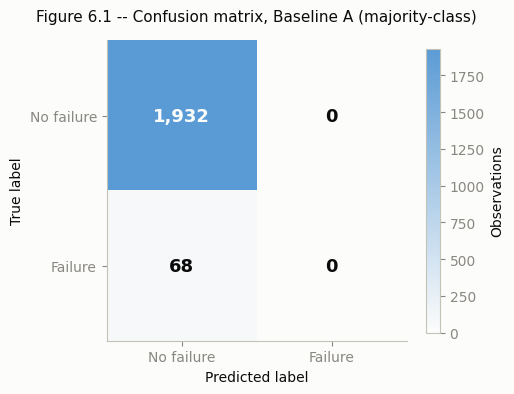

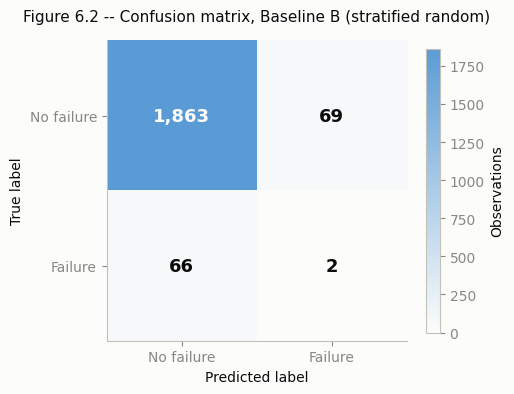

In [69]:
# 6.4 Visualizations: confusion matrices for both baselines

# Reuses the validated palette already established in Task 3 (COLOR_NO_FAILURE,
# TYPE_COLORS, AXIS_COLOR, TEXT_MUTED, TEXT_PRIMARY, the `savefig` helper, and
# the matplotlib rcParams) so these figures read as part of the same report
# rather than a one-off style. Two NEW colour choices are made here, each
# picked by the JOB the colour does, not by looks:
#   - The confusion matrices use a SEQUENTIAL one-hue ramp (white -> the
#     existing "no failure" blue) because a cell here encodes MAGNITUDE (a
#     count of observations), not identity or polarity -- sequential = one
#     hue, light to dark, per the standard color-by-job rule.
#   - The two ROC curves (6.5) use the existing validated TYPE_COLORS
#     violet/teal pair -- already checked in Task 3 as a categorical pair
#     (lightness band, chroma floor, CVD separation) and re-validated here
#     specifically as a 2-slot pair: ΔE 11.9 (deutan) / 19.8 (normal vision),
#     both clearing the >=8 target. It carries a contrast-vs-surface WARN for
#     the violet, so the "relief" it requires -- direct labels rather than
#     colour alone -- is built in via the legend, which spells out AUC for
#     each line rather than relying on the reader to distinguish hue alone.
#     This pair deliberately does NOT reuse the red/green failure-status
#     colours, since "Baseline A" vs "Baseline B" is an identity distinction,
#     not a failure/no-failure one, and reusing that pair here would visually
#     (and wrongly) suggest these lines encode failure status.
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_curve

CONFUSION_CMAP = LinearSegmentedColormap.from_list(
    "blue_sequential", ["#fcfcfb", COLOR_NO_FAILURE], N=256
)
BASELINE_A_COLOR = TYPE_COLORS['H']   # pastel violet -- Baseline A (majority-class)
BASELINE_B_COLOR = TYPE_COLORS['L']   # pastel teal   -- Baseline B (stratified random)


def plot_confusion_matrix(cm, title, filename):
    """Sequential-blue confusion matrix, annotated with counts. Rows = true
    label, columns = predicted label (sklearn's confusion_matrix convention)."""
    fig, ax = plt.subplots(figsize=(5.2, 4.3))
    im = ax.imshow(cm, cmap=CONFUSION_CMAP, vmin=0)
    labels = ['No failure', 'Failure']
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title, fontsize=11)
    ax.grid(False)

    # Contrast-aware annotations: dark text on light cells, light text on
    # dark cells, so counts stay readable across the full range of the ramp
    # (the same "relief" principle as the ROC legend above, applied to marks
    # instead of lines).
    cell_max = cm.max() if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text_color = TEXT_PRIMARY if value < 0.6 * cell_max else "#fcfcfb"
            ax.text(j, i, f"{value:,}", ha='center', va='center',
                     fontsize=13, color=text_color, fontweight='bold')

    fig.colorbar(im, ax=ax, shrink=0.85, label="Observations")
    plt.tight_layout()
    savefig(filename)
    plt.show()


plot_confusion_matrix(
    confusion_matrix(y_test, majority_clf.predict(X_test)),
    "Figure 6.1 -- Confusion matrix, Baseline A (majority-class)",
    "fig6_1_confusion_baseline_a.png",
)

plot_confusion_matrix(
    confusion_matrix(y_test, stratified_clf.predict(X_test)),
    "Figure 6.2 -- Confusion matrix, Baseline B (stratified random)",
    "fig6_2_confusion_baseline_b.png",
)



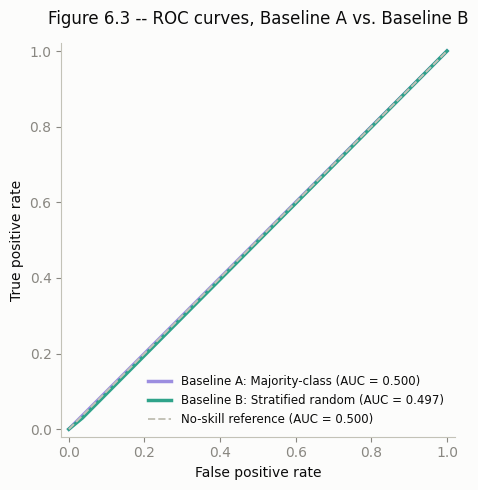

In [70]:
# 6.5 ROC curves for both baselines, on one plot
# Both curves are expected to collapse onto (or closely hug) the diagonal
# "no-skill" reference line -- that collapse IS the intended evidence for
# Task 6: neither baseline has any real discriminative ability, in deliberate
# contrast to the ROC curves Task 9 will plot for the actual Task 7 models
# (which should show visible lift above this same diagonal). Keeping the same
# axes/diagonal convention here means the Task 6 and Task 9 ROC figures will
# read as directly comparable, not two different chart styles.
fig, ax = plt.subplots(figsize=(5, 5))

for clf, color, name in [
    (majority_clf, BASELINE_A_COLOR, "Baseline A: Majority-class"),
    (stratified_clf, BASELINE_B_COLOR, "Baseline B: Stratified random"),
]:
    proba = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], color=AXIS_COLOR, linestyle='--', linewidth=1.4,
        label="No-skill reference (AUC = 0.500)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Figure 6.3 -- ROC curves, Baseline A vs. Baseline B")
ax.legend(frameon=False, loc='lower right', fontsize=8.5)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
plt.tight_layout()
savefig("fig6_3_roc_baselines.png")
plt.show()


## Task 6: Baseline Performance Conclusion

**Baseline design.** Two no-information baselines were built with `sklearn.dummy.DummyClassifier`, deliberately withheld from all five numeric predictors and `Type` so that neither can benefit from anything Task 4/5 established. They are only permitted to see the training set's class distribution. Baseline A (majority-class) always predicts "No failure" regardless of input; Baseline B (stratified random) predicts 0/1 at random, weighted by the training class prior (approximately 3.4% positive). Together they give two different flavours of "doing nothing informative": one that is silent about failures entirely, and one that occasionally guesses positive by pure chance. Both are evaluated on the exact metric set Task 9 will later apply to every real model (accuracy, precision, recall, F1, confusion matrix, ROC-AUC), on the same seed-666 test set (2,000 rows, 68 failures, 3.40%) established in Task 4, so the comparison from Task 7 onward is apples-to-apples.

**Results.** Baseline A reaches 96.60% accuracy, unsurprisingly, since it matches the test set's no-failure share almost exactly, but precision, recall, and F1 are all 0.0000: the confusion matrix (Figure 6.1) shows 1,932 correct no-failure calls and 0 predicted failures, meaning all 68 real failures in the test set are missed (68 false negatives, 0 true positives). Its ROC-AUC is exactly 0.500, the theoretical floor, since it produces a single constant score for every row. Baseline B does slightly worse on accuracy (93.25%) but is not meaningfully better where it matters: it catches only 2 of the 68 real failures (recall 2.94%), at the cost of 69 false alarms on machines that did not fail (Figure 6.2), giving a precision of 2.82% and F1 of 2.88%. Its ROC-AUC (0.4968) is statistically indistinguishable from 0.500. The small dip below it is sampling noise from the random-guessing strategy, not evidence of "worse than random" skill, since its underlying predicted probabilities are constant across all rows (equal to the training class prior). Both curves collapse onto the no-skill diagonal in Figure 6.3, visually confirming neither baseline has any real discriminative ability.

| Metric | Baseline A (majority-class) | Baseline B (stratified random) |
|---|---|---|
| Accuracy | 0.9660 | 0.9325 |
| Precision | 0.0000 | 0.0282 |
| Recall | 0.0000 | 0.0294 |
| F1-score | 0.0000 | 0.0288 |
| ROC-AUC | 0.5000 | 0.4968 |
| Failures caught (of 68) | 0 | 2 |
| False alarms | 0 | 69 |


**What this demonstrates about the difficulty of the problem.** The baseline does not show that this is an unsolvable or even a particularly hard classification problem in the ordinary sense. Task 5 already established that a single raw predictor (Torque alone) reaches 0.771 test AUC, and a plain Logistic Regression using only the five raw sensor variables and `Type` reaches 0.927. What the baseline isolates is that the entire difficulty of this problem is concentrated in identifying a thin slice of the data (68 of 2,000 test rows) rather than in separating the classes once real information is used. A rule that requires no data at all can already get "most of the rows right" simply because the positive class is rare, 96.60% of the test set is trivially correct by construction, so the baseline's near-perfect accuracy is really a statement about the base rate, not about anything having been learned. This is exactly the property that makes the problem hard in practice: any model must extract genuine signal to beat a floor that is already extremely close to 100%, and small absolute gains in accuracy from Task 7 onward may correspond to large relative gains (or losses) in the ability to actually catch failures.

**Why a seemingly strong baseline accuracy may or may not indicate useful predictive performance.** The comparison between the two baselines is the sharpest illustration of this: Baseline A scores *higher* accuracy (96.60%) than Baseline B (93.25%) precisely because it never attempts to flag a single failure, while Baseline B is penalised on accuracy for the 69 false alarms it generates in the process of (barely) catching 2 real failures. An accuracy-only view would rank the completely useless baseline above the marginally-less-useless one. The opposite of what a predictive-maintenance system actually needs, which is to catch failures, not to avoid disturbing the majority class. This confirms, with a concrete number, the argument made in Task 1: 96.60% accuracy sounds like strong performance stated in isolation, but it is achieved here by a rule with zero access to Torque, Tool wear, or any other operating condition, and it corresponds to 0% recall on the class that actually matters operationally. Consequently, no model in Task 7 can be judged as an improvement over this baseline on the strength of its accuracy figure alone; a candidate model must be shown to clear the 0.500 ROC-AUC floor by a real margin and to recover a meaningful share of the 68 failures that both baselines miss (68 of 68 for Baseline A, 66 of 68 for Baseline B) before its accuracy number is allowed to mean anything.


### Task 7. Required Classification Models

Develop the following classification models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

For each model:

- establish an initial version;
- investigate alternative model configurations;
- conduct systematic parameter exploration;
- identify the final selected configuration;
- document your model-selection criterion; and
- justify the final parameter choices.

The submitted work must provide sufficient evidence to demonstrate that parameter exploration actually occurred. Using only default model settings is not sufficient.



In [71]:
# TASK 7 -- REQUIRED CLASSIFICATION MODELS

# NOTE ON RUNTIME: the Random Forest and XGBoost sections each run a
# RandomizedSearchCV with n_iter=40 candidates x 5 CV folds = 200 model fits.
# On the 8,000-row training set this is usually a few minutes per model in
# Colab, not seconds -- that is expected, not a hang. If you want faster
# iteration while testing, temporarily lower n_iter (e.g. to 10) in 7.3.3 /
# 7.4.3 and raise it back before your final run.

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
)

RANDOM_SEED = 666
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# 7.0a Model-selection criterion (applies to all four models below) ----
# Mean cross-validated ROC-AUC is used as the single criterion for both the
# systematic parameter search (the `scoring` argument below) and for
# comparing hand-picked alternative configurations, for the same reason
# Task 6 reported ROC-AUC alongside accuracy: accuracy is a poor selection
# signal on a 96.6% / 3.4% split (Task 6 showed a rule that predicts nothing
# useful can still reach 96.60% accuracy). ROC-AUC is also threshold-
# independent -- no arbitrary 0.5 cut-off is baked into the selection step,
# that decision belongs to Task 10 -- and it is the same metric already used
# to keep/drop features in Task 5, so using it here keeps the selection
# criterion consistent across the whole pipeline rather than switching
# metrics between tasks. All cross-validation below reuses the SAME
# StratifiedKFold object (5 folds, shuffled, seed=666), so every fold
# preserves the ~3.4% failure rate and the four models' CV scores are
# directly comparable to each other.
print(f"Model-selection criterion: mean CV ROC-AUC, {CV.get_n_splits()}-fold "
      f"StratifiedKFold, random_state={RANDOM_SEED}")


Model-selection criterion: mean CV ROC-AUC, 5-fold StratifiedKFold, random_state=666


In [72]:
# 7.0b Final feature set: fold in Task 5's retained engineered features

# Task 4 built preprocessor_scaled/preprocessor_unscaled from Type + the 5
# raw numeric predictors only, before Task 5's features existed. Task 7 uses
# the FINAL retained feature set from Task 5's decision -- Temp differential
# and Mechanical power retained; Torque x Tool wear dropped, per the
# incremental-AUC test, so the ColumnTransformers are rebuilt here rather
# than reusing Task 4's fitted objects. Everything else about the leakage
# discipline established in Task 4 is unchanged: fit on X_train only,
# applied (never re-fit) to X_test.
model_numeric_cols = numeric_cols + ['Temp differential [K]', 'Mechanical power [W]']

cat_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
cat_encoder.fit(X_train[categorical_cols])

num_scaler = StandardScaler()
num_scaler.fit(X_train[model_numeric_cols])

preprocessor_model_scaled = ColumnTransformer([
    ('cat', cat_encoder, categorical_cols),
    ('num', num_scaler, model_numeric_cols),
])
preprocessor_model_unscaled = ColumnTransformer([
    ('cat', cat_encoder, categorical_cols),
    ('num', 'passthrough', model_numeric_cols),
])

Xtr_scaled = preprocessor_model_scaled.fit_transform(X_train[categorical_cols + model_numeric_cols])
Xte_scaled = preprocessor_model_scaled.transform(X_test[categorical_cols + model_numeric_cols])
Xtr_unscaled = preprocessor_model_unscaled.fit_transform(X_train[categorical_cols + model_numeric_cols])
Xte_unscaled = preprocessor_model_unscaled.transform(X_test[categorical_cols + model_numeric_cols])

feature_names = preprocessor_model_scaled.get_feature_names_out()
print("Final feature set:", list(feature_names))
print("Scaled design matrix   (Logistic Regression)          :", Xtr_scaled.shape)
print("Unscaled design matrix (Decision Tree / RF / XGBoost) :", Xtr_unscaled.shape)

# Usage below:
#   Logistic Regression                   -> Xtr_scaled   / Xte_scaled
#   Decision Tree, Random Forest, XGBoost -> Xtr_unscaled / Xte_unscaled


# ---- shared evaluation helper (same metric set as Task 6, for direct comparison) ----
def evaluate_model(model, X_test_, y_test_, name):
    y_pred = model.predict(X_test_)
    y_proba = model.predict_proba(X_test_)[:, 1]
    acc = accuracy_score(y_test_, y_pred)
    prec = precision_score(y_test_, y_pred, zero_division=0)
    rec = recall_score(y_test_, y_pred, zero_division=0)
    f1 = f1_score(y_test_, y_pred, zero_division=0)
    auc = roc_auc_score(y_test_, y_proba)
    cm = confusion_matrix(y_test_, y_pred)
    print(f"\n{'-' * 60}\n{name}\n{'-' * 60}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print("Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):")
    print(cm)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': auc}


def compare_configs(configs, X_tr, y_tr, cv=CV):
    """Hand-picked alternative configurations, compared by mean CV ROC-AUC
    BEFORE any automated search -- the 'investigate alternative model
    configurations' step the assignment asks for, kept separate from the
    systematic grid/random search that follows it."""
    rows = []
    for label, est in configs:
        scores = cross_val_score(est, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
        rows.append({'Configuration': label, 'Mean CV ROC-AUC': scores.mean(), 'Std': scores.std()})
        print(f"  {label:48s} mean CV ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")
    return pd.DataFrame(rows)



Final feature set: ['cat__Type_L', 'cat__Type_M', 'num__Air temperature [K]', 'num__Process temperature [K]', 'num__Rotational speed [rpm]', 'num__Torque [Nm]', 'num__Tool wear [min]', 'num__Temp differential [K]', 'num__Mechanical power [W]']
Scaled design matrix   (Logistic Regression)          : (8000, 9)
Unscaled design matrix (Decision Tree / RF / XGBoost) : (8000, 9)


In [73]:
# 7.1 -- LOGISTIC REGRESSION

# 7.1.1 Initial version (library defaults)

logreg_initial = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
logreg_initial.fit(Xtr_scaled, y_train)
logreg_initial_results = evaluate_model(logreg_initial, Xte_scaled, y_test,
                                         "7.1.1 Logistic Regression -- initial (defaults)")

# 7.1.2 Alternative configurations investigated
# Hand-picked, before any automated search: does regularization strength
# matter, does the penalty type matter, and -- most importantly given the
# 3.4% failure rate -- does reweighting the loss for class imbalance
# (class_weight='balanced') change anything, since nothing in the pipeline
# so far (Task 4/6) has corrected for imbalance.
print("\n7.1.2 Alternative configurations (hand-picked, before systematic search):")
logreg_configs = [
    ("Default (C=1.0, l2, no class_weight)", LogisticRegression(solver='liblinear', random_state=RANDOM_SEED, max_iter=1000)),
    ("Strong regularization (C=0.01, l2)", LogisticRegression(C=0.01, solver='liblinear', random_state=RANDOM_SEED, max_iter=1000)),
    ("Weak regularization (C=10, l2)", LogisticRegression(C=10, solver='liblinear', random_state=RANDOM_SEED, max_iter=1000)),
    ("L1 penalty (C=1.0, liblinear)", LogisticRegression(penalty='l1', solver='liblinear', random_state=RANDOM_SEED, max_iter=1000)),
    ("class_weight='balanced' (C=1.0, l2)", LogisticRegression(class_weight='balanced', solver='liblinear', random_state=RANDOM_SEED, max_iter=1000)),
]
logreg_config_comparison = compare_configs(logreg_configs, Xtr_scaled, y_train)

# 7.1.3 Systematic parameter exploration
# GridSearchCV (exhaustive cheap enough for Logistic Regression) over
# regularization strength, penalty type and class-weighting jointly.
# solver='liblinear' supports both l1 and l2 penalties, so it is fixed
# across the grid to keep the penalty comparison apples-to-apples.
logreg_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced'],
}
logreg_search = GridSearchCV(
    LogisticRegression(solver='liblinear', random_state=RANDOM_SEED, max_iter=1000),
    param_grid=logreg_param_grid, scoring='roc_auc', cv=CV, n_jobs=-1, refit=True,
)
logreg_search.fit(Xtr_scaled, y_train)
n_candidates = len(logreg_search.cv_results_['params'])
print(f"\n7.1.3 Grid search: {n_candidates} candidate configurations x "
      f"{CV.get_n_splits()} folds = {n_candidates * CV.get_n_splits()} fits")
print("Best CV ROC-AUC:", round(logreg_search.best_score_, 4))
print("Best params:", logreg_search.best_params_)

# ---- 7.1.4 / 7.1.5 Final selected configuration ----
logreg_final = logreg_search.best_estimator_
logreg_final_results = evaluate_model(logreg_final, Xte_scaled, y_test,
                                       "7.1.5 Logistic Regression -- FINAL (grid search)")




------------------------------------------------------------
7.1.1 Logistic Regression -- initial (defaults)
------------------------------------------------------------
Accuracy:  0.9715
Precision: 0.6897
Recall:    0.2941
F1-score:  0.4124
ROC-AUC:   0.9342
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1923    9]
 [  48   20]]

7.1.2 Alternative configurations (hand-picked, before systematic search):
  Default (C=1.0, l2, no class_weight)             mean CV ROC-AUC = 0.9147 (+/- 0.0128)
  Strong regularization (C=0.01, l2)               mean CV ROC-AUC = 0.8395 (+/- 0.0199)
  Weak regularization (C=10, l2)                   mean CV ROC-AUC = 0.9188 (+/- 0.0129)
  L1 penalty (C=1.0, liblinear)                    mean CV ROC-AUC = 0.9183 (+/- 0.0129)
  class_weight='balanced' (C=1.0, l2)              mean CV ROC-AUC = 0.9214 (+/- 0.0129)

7.1.3 Grid search: 24 candidate configurations x 5 folds = 120 fits
Best CV ROC-AUC: 0.9217
Best params: {'C': 10, 'class_weight': 

In [74]:
# 7.2. DECISION TREE

#  7.2.1 Initial version (library defaults)
tree_initial = DecisionTreeClassifier(random_state=RANDOM_SEED)
tree_initial.fit(Xtr_unscaled, y_train)
tree_initial_results = evaluate_model(tree_initial, Xte_unscaled, y_test,
                                       "7.2.1 Decision Tree -- initial (defaults)")
print(f"Unconstrained tree depth reached: {tree_initial.get_depth()}, leaves: {tree_initial.get_n_leaves()}")

# 7.2.2 Alternative configurations investigated
# An unconstrained default tree can grow to the depth printed above, which on
# an 8,000-row training set is a real overfitting risk; the hand-picked
# alternatives below probe depth constraints, leaf-size constraints, and
# class_weight='balanced' as three independent, easy-to-reason-about levers
# before the joint systematic search.
print("\n7.2.2 Alternative configurations (hand-picked, before systematic search):")
tree_configs = [
    ("Default (unconstrained)", DecisionTreeClassifier(random_state=RANDOM_SEED)),
    ("max_depth=5", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_SEED)),
    ("max_depth=10", DecisionTreeClassifier(max_depth=10, random_state=RANDOM_SEED)),
    ("min_samples_leaf=20", DecisionTreeClassifier(min_samples_leaf=20, random_state=RANDOM_SEED)),
    ("class_weight='balanced' (unconstrained)", DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_SEED)),
]
tree_config_comparison = compare_configs(tree_configs, Xtr_unscaled, y_train)

# 7.2.3 Systematic parameter exploration
tree_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 10, 20],
    'class_weight': [None, 'balanced'],
    'criterion': ['gini', 'entropy'],
}
tree_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_SEED),
    param_grid=tree_param_grid, scoring='roc_auc', cv=CV, n_jobs=-1, refit=True,
)
tree_search.fit(Xtr_unscaled, y_train)
n_candidates = len(tree_search.cv_results_['params'])
print(f"\n7.2.3 Grid search: {n_candidates} candidate configurations x "
      f"{CV.get_n_splits()} folds = {n_candidates * CV.get_n_splits()} fits")
print("Best CV ROC-AUC:", round(tree_search.best_score_, 4))
print("Best params:", tree_search.best_params_)

# 7.2.4 / 7.2.5 Final selected configuration
tree_final = tree_search.best_estimator_
tree_final_results = evaluate_model(tree_final, Xte_unscaled, y_test,
                                     "7.2.5 Decision Tree -- FINAL (grid search)")
print(f"Final tree depth: {tree_final.get_depth()}, leaves: {tree_final.get_n_leaves()}")




------------------------------------------------------------
7.2.1 Decision Tree -- initial (defaults)
------------------------------------------------------------
Accuracy:  0.9830
Precision: 0.7500
Recall:    0.7500
F1-score:  0.7500
ROC-AUC:   0.8706
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1915   17]
 [  17   51]]
Unconstrained tree depth reached: 19, leaves: 107

7.2.2 Alternative configurations (hand-picked, before systematic search):
  Default (unconstrained)                          mean CV ROC-AUC = 0.8708 (+/- 0.0468)
  max_depth=5                                      mean CV ROC-AUC = 0.9667 (+/- 0.0103)
  max_depth=10                                     mean CV ROC-AUC = 0.9213 (+/- 0.0316)
  min_samples_leaf=20                              mean CV ROC-AUC = 0.9549 (+/- 0.0270)
  class_weight='balanced' (unconstrained)          mean CV ROC-AUC = 0.8662 (+/- 0.0385)

7.2.3 Grid search: 288 candidate configurations x 5 folds = 1440 fits
Best CV ROC-AUC: 

In [75]:
# 7.3 -- RANDOM FOREST

# 7.3.1 Initial version (library defaults)
rf_initial = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
rf_initial.fit(Xtr_unscaled, y_train)
rf_initial_results = evaluate_model(rf_initial, Xte_unscaled, y_test,
                                     "7.3.1 Random Forest -- initial (defaults)")

# 7.3.2 Alternative configurations investigated
print("\n7.3.2 Alternative configurations (hand-picked, before systematic search):")
rf_configs = [
    ("Default (100 trees, unconstrained depth)", RandomForestClassifier(random_state=RANDOM_SEED)),
    ("More trees (n_estimators=300)", RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED)),
    ("Shallower trees (max_depth=8)", RandomForestClassifier(max_depth=8, random_state=RANDOM_SEED)),
    ("min_samples_leaf=10", RandomForestClassifier(min_samples_leaf=10, random_state=RANDOM_SEED)),
    ("class_weight='balanced'", RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED)),
]
rf_config_comparison = compare_configs(rf_configs, Xtr_unscaled, y_train)

# 7.3.3 Systematic parameter exploration
# RandomizedSearchCV rather than GridSearchCV here: the joint grid across 6
# hyperparameters is large enough (thousands of combinations) that an
# exhaustive search would be expensive for limited additional benefit, so a
# fixed budget of n_iter randomly sampled combinations is used instead --
# still systematic (fixed search space, fixed scoring, fixed CV, fixed seed),
# just not exhaustive.
rf_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [5, 8, 10, 15, 20, None],
    'min_samples_leaf': randint(1, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED),
    param_distributions=rf_param_dist, n_iter=40, scoring='roc_auc', cv=CV,
    n_jobs=-1, random_state=RANDOM_SEED, refit=True,
)
rf_search.fit(Xtr_unscaled, y_train)
print(f"\n7.3.3 Randomized search: {rf_search.n_iter} candidate configurations sampled x "
      f"{CV.get_n_splits()} folds = {rf_search.n_iter * CV.get_n_splits()} fits")
print("Best CV ROC-AUC:", round(rf_search.best_score_, 4))
print("Best params:", rf_search.best_params_)

# 7.3.4 / 7.3.5 Final selected configuration
rf_final = rf_search.best_estimator_
rf_final_results = evaluate_model(rf_final, Xte_unscaled, y_test,
                                   "7.3.5 Random Forest -- FINAL (randomized search)")

# 7.3.6 Feature importances (context for Task 12, printed here for convenience)
rf_importances = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values(ascending=False)
print("\nRandom Forest feature importances (final model):")
print(rf_importances.round(4))


------------------------------------------------------------
7.3.1 Random Forest -- initial (defaults)
------------------------------------------------------------
Accuracy:  0.9890
Precision: 0.9600
Recall:    0.7059
F1-score:  0.8136
ROC-AUC:   0.9710
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1930    2]
 [  20   48]]

7.3.2 Alternative configurations (hand-picked, before systematic search):
  Default (100 trees, unconstrained depth)         mean CV ROC-AUC = 0.9655 (+/- 0.0164)
  More trees (n_estimators=300)                    mean CV ROC-AUC = 0.9742 (+/- 0.0090)
  Shallower trees (max_depth=8)                    mean CV ROC-AUC = 0.9772 (+/- 0.0106)
  min_samples_leaf=10                              mean CV ROC-AUC = 0.9742 (+/- 0.0121)
  class_weight='balanced'                          mean CV ROC-AUC = 0.9664 (+/- 0.0179)

7.3.3 Randomized search: 40 candidate configurations sampled x 5 folds = 200 fits
Best CV ROC-AUC: 0.9784
Best params: {'class_weight': N

In [76]:
# 7.4  XGBOOST

# 7.4.1 Initial version (library defaults)
xgb_initial = XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', n_jobs=-1)
xgb_initial.fit(Xtr_unscaled, y_train)
xgb_initial_results = evaluate_model(xgb_initial, Xte_unscaled, y_test,
                                      "7.4.1 XGBoost -- initial (defaults)")

#  7.4.2 Alternative configurations investigated
# scale_pos_weight is XGBoost's equivalent of class_weight='balanced' -- the
# ratio of negative to positive training examples -- so it is computed here
# from y_train rather than hand-picked, following the imbalance strategy
# staged (but not yet applied) back in Task 4 (4.8).
neg_count, pos_count = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count
print(f"\nComputed scale_pos_weight (train neg/pos ratio): {scale_pos_weight_value:.2f}")

print("7.4.2 Alternative configurations (hand-picked, before systematic search):")
xgb_configs = [
    ("Default (100 trees, depth 6, lr 0.3)", XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss')),
    ("More trees, lower learning rate", XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_SEED, eval_metric='logloss')),
    ("Shallower trees (max_depth=3)", XGBClassifier(max_depth=3, random_state=RANDOM_SEED, eval_metric='logloss')),
    ("Subsampling (subsample=0.8, colsample=0.8)", XGBClassifier(subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, eval_metric='logloss')),
    (f"scale_pos_weight={scale_pos_weight_value:.1f} (imbalance-aware)", XGBClassifier(scale_pos_weight=scale_pos_weight_value, random_state=RANDOM_SEED, eval_metric='logloss')),
]
xgb_config_comparison = compare_configs(xgb_configs, Xtr_unscaled, y_train)

# 7.4.3 Systematic parameter exploration
xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(2, 10),
    'learning_rate': uniform(0.01, 0.29),     # ~0.01 to 0.30
    'subsample': uniform(0.6, 0.4),           # ~0.6 to 1.0
    'colsample_bytree': uniform(0.6, 0.4),    # ~0.6 to 1.0
    'scale_pos_weight': [1, scale_pos_weight_value],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss'),
    param_distributions=xgb_param_dist, n_iter=40, scoring='roc_auc', cv=CV,
    n_jobs=-1, random_state=RANDOM_SEED, refit=True,
)
xgb_search.fit(Xtr_unscaled, y_train)
print(f"\n7.4.3 Randomized search: {xgb_search.n_iter} candidate configurations sampled x "
      f"{CV.get_n_splits()} folds = {xgb_search.n_iter * CV.get_n_splits()} fits")
print("Best CV ROC-AUC:", round(xgb_search.best_score_, 4))
print("Best params:", xgb_search.best_params_)

# 7.4.4 / 7.4.5 Final selected configuration
xgb_final = xgb_search.best_estimator_
xgb_final_results = evaluate_model(xgb_final, Xte_unscaled, y_test,
                                    "7.4.5 XGBoost -- FINAL (randomized search)")



------------------------------------------------------------
7.4.1 XGBoost -- initial (defaults)
------------------------------------------------------------
Accuracy:  0.9845
Precision: 0.8627
Recall:    0.6471
F1-score:  0.7395
ROC-AUC:   0.9753
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1925    7]
 [  24   44]]

Computed scale_pos_weight (train neg/pos ratio): 28.52
7.4.2 Alternative configurations (hand-picked, before systematic search):
  Default (100 trees, depth 6, lr 0.3)             mean CV ROC-AUC = 0.9750 (+/- 0.0138)
  More trees, lower learning rate                  mean CV ROC-AUC = 0.9774 (+/- 0.0127)
  Shallower trees (max_depth=3)                    mean CV ROC-AUC = 0.9734 (+/- 0.0127)
  Subsampling (subsample=0.8, colsample=0.8)       mean CV ROC-AUC = 0.9724 (+/- 0.0102)
  scale_pos_weight=28.5 (imbalance-aware)          mean CV ROC-AUC = 0.9737 (+/- 0.0125)

7.4.3 Randomized search: 40 candidate configurations sampled x 5 folds = 200 fits
Best C

In [77]:
# 7.5 -- Summary: all four models, initial vs. final, vs. Task 6 baseline

task7_summary = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Stage': 'Initial (defaults)', **logreg_initial_results},
    {'Model': 'Logistic Regression', 'Stage': 'Final (grid search)', **logreg_final_results},
    {'Model': 'Decision Tree', 'Stage': 'Initial (defaults)', **tree_initial_results},
    {'Model': 'Decision Tree', 'Stage': 'Final (grid search)', **tree_final_results},
    {'Model': 'Random Forest', 'Stage': 'Initial (defaults)', **rf_initial_results},
    {'Model': 'Random Forest', 'Stage': 'Final (randomized search)', **rf_final_results},
    {'Model': 'XGBoost', 'Stage': 'Initial (defaults)', **xgb_initial_results},
    {'Model': 'XGBoost', 'Stage': 'Final (randomized search)', **xgb_final_results},
])
print("\n" + "=" * 70)
print("Task 7 summary -- all models, all stages")
print("=" * 70)
print(task7_summary[['Model', 'Stage', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
      .round(4).to_string(index=False))

print("\nBest mean CV ROC-AUC per model (from the systematic search, i.e. the")
print("model-selection criterion itself, not the test-set score):")
print(f"  Logistic Regression : {logreg_search.best_score_:.4f}")
print(f"  Decision Tree        : {tree_search.best_score_:.4f}")
print(f"  Random Forest        : {rf_search.best_score_:.4f}")
print(f"  XGBoost              : {xgb_search.best_score_:.4f}")
print("\nFor reference -- Task 6 baseline floor: ROC-AUC = 0.5000 (majority-class), "
      "0.4968 (stratified random)")


Task 7 summary -- all models, all stages
              Model                     Stage  accuracy  precision  recall     f1  roc_auc
Logistic Regression        Initial (defaults)    0.9715     0.6897  0.2941 0.4124   0.9342
Logistic Regression       Final (grid search)    0.8415     0.1570  0.8382 0.2645   0.9274
      Decision Tree        Initial (defaults)    0.9830     0.7500  0.7500 0.7500   0.8706
      Decision Tree       Final (grid search)    0.9860     0.8333  0.7353 0.7812   0.9504
      Random Forest        Initial (defaults)    0.9890     0.9600  0.7059 0.8136   0.9710
      Random Forest Final (randomized search)    0.9865     0.9184  0.6618 0.7692   0.9786
            XGBoost        Initial (defaults)    0.9845     0.8627  0.6471 0.7395   0.9753
            XGBoost Final (randomized search)    0.9805     0.9394  0.4559 0.6139   0.9810

Best mean CV ROC-AUC per model (from the systematic search, i.e. the
model-selection criterion itself, not the test-set score):
  Logistic